# 串扰仿真 v30 —— 参数字典驱动的四步滤噪

按固定顺序跑：

| 步骤 | 配置 | 看什么 |
|---|---|---|
| **i** | Excel 时序 | 模组鬼影 + 对射（基线） |
| **ii** | + tcode | 模组鬼影应被 XM 清掉，对射仍在 |
| **iii** | + FPGA 累计抖动（**双方**） | 最坏对射：同型号、同时序、同 tcode；双方都有 FPGA |
| **iv** | + 一字滤波 | 三角度=三次独立 iii（雷达参数同、种子不同）→ 清角度孤点 |

## v30 默认开关

- tcode：**考虑**激光编号间隔可忽略（`consider_gap=True`，阈值 2）
- tcode 码表验收标准：**必须完全滤干净**——1~600m 扫描鬼影残留 0、真峰误杀 0；
  满足后才在零残留解里压最短预算。
  当前 `XM.ratio=1.5` → **32ns**；`XM.ratio=2.5` → **24ns**（= 约束硬下界）
- XM：**不考虑**信号脉宽（理想 δ 回波，`use_pulse_width=False`）

## 绘图规范

- 发光时序：kick 栅格
- tcode：kick × 激光器矩阵
- 回波：逐回波堆叠柱；绿=真，橙=模组鬼影，红斜线=对射；黑叉=XM 滤除


In [1]:
# ============================================================================
# 0. 导入
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors as mcolors
import openpyxl
from collections import defaultdict, Counter
from matplotlib.patches import Patch

for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [_f]
        break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

C_LIGHT = 2.99792458e8
NS = 1e-9
KICK_SPACING = 2.2e-6
TOF_WINDOW = 2000e-9
D_UNAMBIG = TOF_WINDOW * C_LIGHT / 2.0
KICK_PERIOD_NS = KICK_SPACING / NS

print("0. 导入完成")
print(f"  KICK_SPACING={KICK_SPACING*1e6:.2f}μs, TOF_WINDOW={TOF_WINDOW*1e9:.0f}ns, "
      f"D_UNAMBIG={D_UNAMBIG:.1f}m")


0. 导入完成
  KICK_SPACING=2.20μs, TOF_WINDOW=2000ns, D_UNAMBIG=299.8m


In [2]:
# ============================================================================
# 1. 导入 Excel 发光时序
# ============================================================================
EXCEL_FILE = "Elephant 时序表.xlsx"
wb = openpyxl.load_workbook(EXCEL_FILE, data_only=True)
ws = wb["长焦"]
COL_A = range(8, 24)

tdelay_A = {}
for c in COL_A:
    v = ws.cell(4, c).value
    tdelay_A[c - 8] = int(v) if v is not None else 0

laser_fires_raw = []
laser_ids = []
for r in range(7, 106):
    las = ws.cell(r, 6).value
    if las is None:
        continue
    try:
        lid = int(las)
    except (ValueError, TypeError):
        continue
    laser_ids.append(lid)
    for k, c in enumerate(COL_A):
        v = ws.cell(r, c).value
        if v is not None:
            laser_fires_raw.append((lid, k, int(v)))

laser_ids = sorted(set(laser_ids))
N_LASERS = len(laser_ids)
SHOT_KICKS = {lid: sorted(k for (l, k, tx) in laser_fires_raw if l == lid)
              for lid in laser_ids}
EXCEL_TX = {(l, k): tx for (l, k, tx) in laser_fires_raw}
N_ACC = int(np.median([len(v) for v in SHOT_KICKS.values()]))

def laser_color(laser_id):
    idx = (laser_id - 1) % max(N_LASERS, 1)
    return mcolors.hsv_to_rgb((idx / max(N_LASERS, 1), 0.65, 0.92))

print(f"1. 从 {EXCEL_FILE} [长焦/A组] 读取：{N_LASERS} 激光器，"
      f"{len(laser_fires_raw)} 次发光")
for lid in laser_ids:
    print(f"  L{lid:>2d}: {SHOT_KICKS[lid]}")


1. 从 Elephant 时序表.xlsx [长焦/A组] 读取：16 激光器，64 次发光
  L 1: [7, 8, 9, 15]
  L 2: [11, 12, 13, 14]
  L 3: [7, 8, 9, 15]
  L 4: [11, 12, 13, 14]
  L 5: [0, 1, 2, 6]
  L 6: [3, 4, 5, 10]
  L 7: [0, 1, 2, 6]
  L 8: [3, 4, 5, 10]
  L 9: [0, 1, 2, 6]
  L10: [3, 4, 5, 10]
  L11: [0, 1, 2, 6]
  L12: [3, 4, 5, 10]
  L13: [7, 8, 9, 15]
  L14: [11, 12, 13, 14]
  L15: [7, 8, 9, 15]
  L16: [11, 12, 13, 14]


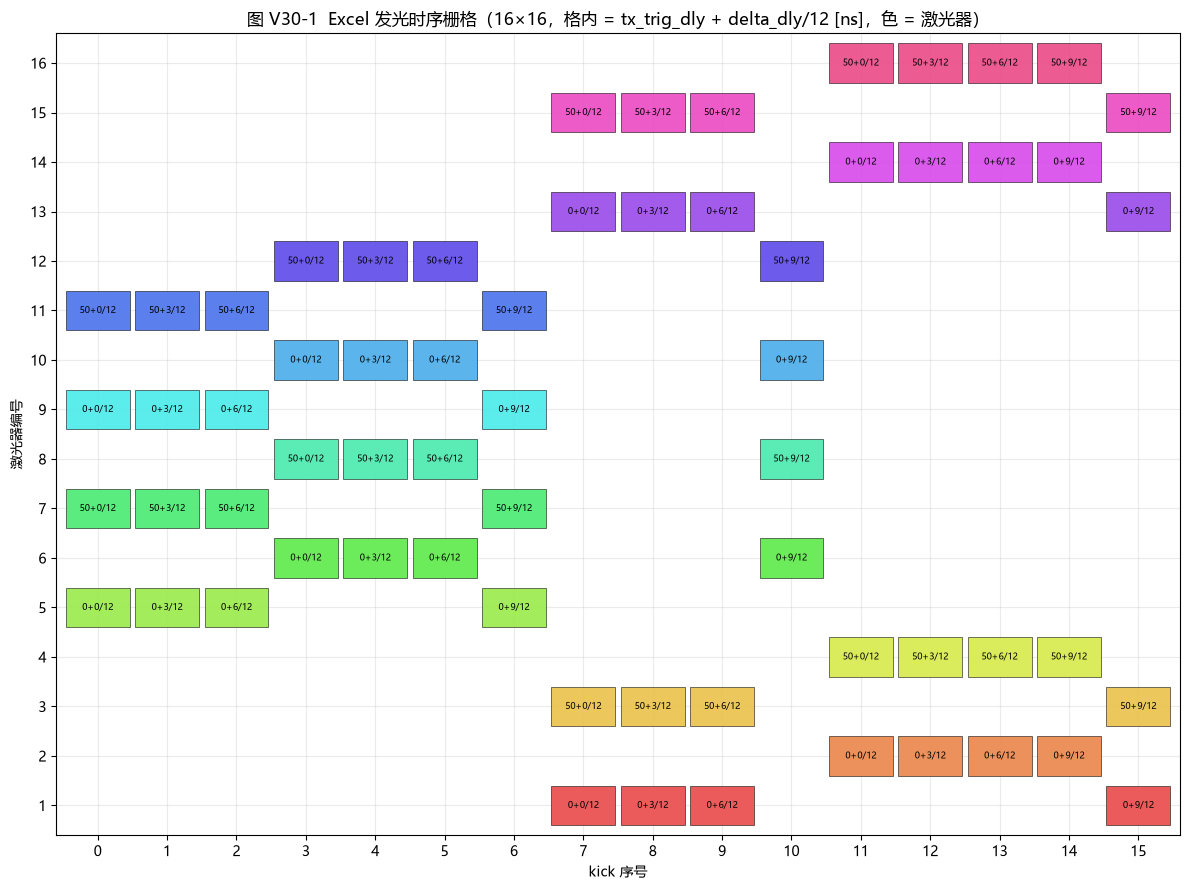

1b. delta_dly（Excel 第4行 tdelay，1/12 ns 步长，按 kick）：
  kick :   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15
  delta:   0   3   6   0   3   6   9   0   3   6   9   0   3   6   9   9


In [3]:
# ============================================================================
# 1b. 发光时序 kick 栅格（项目统一风格）
# ============================================================================
# 格内 = tx_trig_dly + delta_dly/12，单位 ns。
#   tx_trig_dly : 1 ns 步长（Excel 各 kick 的发光延时）
#   delta_dly   : 1/12 ns 步长（Excel 第 4 行 tdelay，按 kick 给出，与激光器无关）
def plot_kick_grid(label_of, title):
    fig, ax = plt.subplots(figsize=(12, 9))
    for lid in laser_ids:
        for k in SHOT_KICKS[lid]:
            ax.add_patch(plt.Rectangle(
                (k - 0.46, lid - 0.40), 0.92, 0.80,
                facecolor=laser_color(lid), edgecolor="k",
                linewidth=0.4, alpha=0.95, zorder=2))
            ax.text(k, lid, f"{label_of(lid, k)}", fontsize=6.5,
                    ha="center", va="center", color="k", zorder=3)
    ax.set_xticks(range(16)); ax.set_yticks(laser_ids)
    ax.set_xlim(-0.6, 15.6); ax.set_ylim(0.4, N_LASERS + 0.6)
    ax.set_xlabel("kick 序号")
    ax.set_ylabel("激光器编号")
    ax.set_title(title)
    ax.grid(alpha=0.25, zorder=0); ax.set_axisbelow(True)
    plt.tight_layout(); plt.show()


def code_label(tx_ns, kick):
    return f"{tx_ns}+{tdelay_A.get(kick, 0)}/12"


plot_kick_grid(lambda lid, k: code_label(EXCEL_TX[(lid, k)], k),
               f"图 V30-1  Excel 发光时序栅格（{N_LASERS}×16，"
               f"格内 = tx_trig_dly + delta_dly/12 [ns]，色 = 激光器）")

print("1b. delta_dly（Excel 第4行 tdelay，1/12 ns 步长，按 kick）：")
print("  kick : " + " ".join(f"{k:>3d}" for k in range(16)))
print("  delta: " + " ".join(f"{tdelay_A[k]:>3d}" for k in range(16)))


In [4]:
# ============================================================================
# 2. 全局参数字典
# ============================================================================
# ---- 场景 ----
SCENE = {
    "demo_D_m": 150.0,          # 演示目标距离 [m]
    "demo_laser": 5,            # 单通道解剖激光器
    "line_D_left_m": 150.0,     # 一字滤波左角度距离
    "line_D_mid_m": 150.0,
    "line_D_right_m": 150.0,
}

# ---- 发光时序编码 ----
TIMING = {
    "use_tx_trig_dly": True,    # 1 ns 步长（Excel 或 tcode 码值）
    "use_delta_dly": False,     # 1/12 ns 步长；本版默认关（与 v13/v23 一致）
                                # 打开后：t_fire 加 delta，t_ref 减回去（只影响发光时刻）
}

# ---- XM（XtalkMark，串扰标记）----
XM = {
    "ratio": 1.5,               # hist_max × ratio > hist_add → 丢掉
    "use_pulse_width": False,   # v30 默认：不考虑脉宽，理想 δ 回波
    "pulse_width_ns": 8.0,      # 仅当 use_pulse_width=True 时启用
    "hist_bin_ns": 1.0,
    "use_negligible": False,    # 直方图是否计入空间可忽略串扰
}

# ---- tcode ----
# 码表选择规则：必须先满足「1~600m 扫描鬼影零残留、真峰零误杀」，
# 再在零残留解里取最短预算。不接受"只满足约束但有残留"的更短码表。
TCODE = {
    "enable": True,
    "ratio_mode": "1.5",        # 跟 XM.ratio 对齐："1.5" → 32ns；"2.5" → 24ns
    "consider_gap": True,       # v30 默认：考虑激光不串扰距离
    "max_gap": 2,               # 编号间隔 > max_gap 视为可忽略
    "sep_ns": 12,
    "budget_ns_r15": 32,     # ratio=1.5 零残留最短预算
    "budget_ns_r25": 24,     # ratio=2.5 零残留最短预算（= 约束硬下界）
}

# ---- FPGA 累计抖动 ----
FPGA = {
    "enable": False,            # 逐步打开；步骤 iii 再开
    "global_delay_ns": 8,
    "step_ns": 8,
    "n_levels": 8,              # 增量 ∈ step × {0..n_levels-1}
    "seed_ours": 30,
    "seed_radar": 31,           # 对射雷达独立种子（最坏：也有 jitter）
    "shared_across_lasers": True,  # 全模组共用 g[k]，不破坏 tcode 码差
}

# ---- 雷达对射 ----
RADAR = {
    "enable": True,
    "phase_ns": 700.0,          # 名义落点，与真目标 150m 错开
    "same_model": True,         # 同型号
    "same_timing": True,        # 同时序
    "same_tcode": True,         # 同 tcode 版本（步骤 iii 最坏设定）
}

# ---- 一字滤波 ----
LINE = {
    "enable": False,
    "thr_m": 3.0,               # 左右距离差都 > thr → 丢掉
    # 三角度 = 三次独立的 iii 仿真；雷达参数不变，仅随机种子不同
    # 中间角度默认沿用 FPGA.seed_*（与步骤 iii 一致）；左右另给种子
    "seed_ours_left": 40,
    "seed_radar_left": 41,
    "seed_ours_right": 44,
    "seed_radar_right": 45,
}

print("2. 全局参数")
for name, d in [("SCENE", SCENE), ("TIMING", TIMING), ("XM", XM),
                ("TCODE", TCODE), ("FPGA", FPGA), ("RADAR", RADAR),
                ("LINE", LINE)]:
    print("  " + name + ": {")
    for k, v in d.items():
        print(f"    {k}: {v}")
    print("  }")


2. 全局参数
  SCENE: {
    demo_D_m: 150.0
    demo_laser: 5
    line_D_left_m: 150.0
    line_D_mid_m: 150.0
    line_D_right_m: 150.0
  }
  TIMING: {
    use_tx_trig_dly: True
    use_delta_dly: False
  }
  XM: {
    ratio: 1.5
    use_pulse_width: False
    pulse_width_ns: 8.0
    hist_bin_ns: 1.0
    use_negligible: False
  }
  TCODE: {
    enable: True
    ratio_mode: 1.5
    consider_gap: True
    max_gap: 2
    sep_ns: 12
    budget_ns_r15: 32
    budget_ns_r25: 24
  }
  FPGA: {
    enable: False
    global_delay_ns: 8
    step_ns: 8
    n_levels: 8
    seed_ours: 30
    seed_radar: 31
    shared_across_lasers: True
  }
  RADAR: {
    enable: True
    phase_ns: 700.0
    same_model: True
    same_timing: True
    same_tcode: True
  }
  LINE: {
    enable: False
    thr_m: 3.0
    seed_ours_left: 40
    seed_radar_left: 41
    seed_ours_right: 44
    seed_radar_right: 45
  }


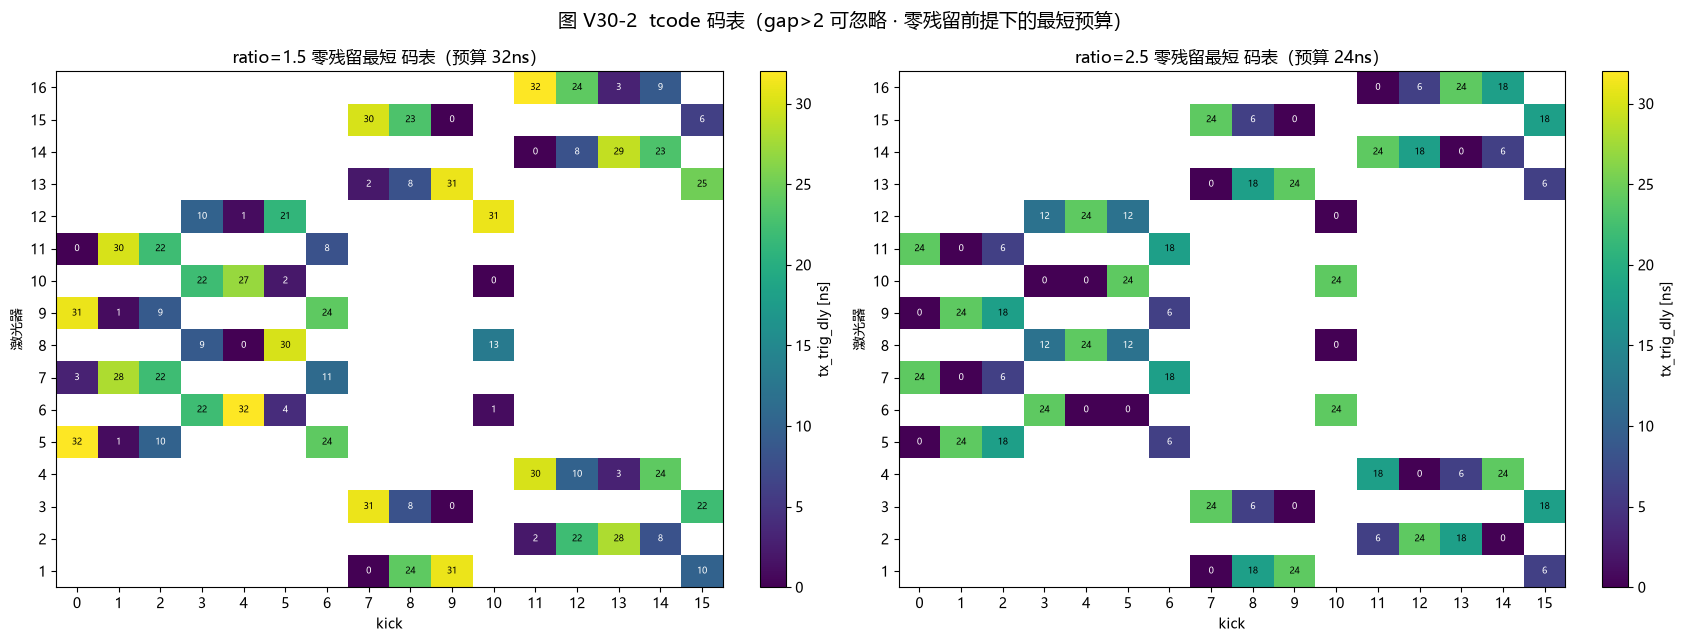

当前 TCODE.ratio_mode=1.5（XM.ratio=1.5），consider_gap=True，预算=32ns
验收标准：1~600m 扫描鬼影残留 0、真峰误杀 0；再在此前提下压最短预算


In [5]:
# ============================================================================
# 2b. 加载 tcode 码表并画矩阵
#    两张码表都已按「1~600m 扫描零鬼影残留 + 零真峰误杀」验收，
#    并在满足该条件的解里压到最短预算：
#      ratio=1.5 → 32ns    ratio=2.5 → 24ns（= 约束硬下界）
# ============================================================================
TCODE_R15 = {
    (1,7):  0, (1,8): 24, (1,9): 31, (1,15): 10,
    (2,11):  2, (2,12): 22, (2,13): 28, (2,14):  8,
    (3,7): 31, (3,8):  8, (3,9):  0, (3,15): 22,
    (4,11): 30, (4,12): 10, (4,13):  3, (4,14): 24,
    (5,0): 32, (5,1):  1, (5,2): 10, (5,6): 24,
    (6,3): 22, (6,4): 32, (6,5):  4, (6,10):  1,
    (7,0):  3, (7,1): 28, (7,2): 22, (7,6): 11,
    (8,3):  9, (8,4):  0, (8,5): 30, (8,10): 13,
    (9,0): 31, (9,1):  1, (9,2):  9, (9,6): 24,
    (10,3): 22, (10,4): 27, (10,5):  2, (10,10):  0,
    (11,0):  0, (11,1): 30, (11,2): 22, (11,6):  8,
    (12,3): 10, (12,4):  1, (12,5): 21, (12,10): 31,
    (13,7):  2, (13,8):  8, (13,9): 31, (13,15): 25,
    (14,11):  0, (14,12):  8, (14,13): 29, (14,14): 23,
    (15,7): 30, (15,8): 23, (15,9):  0, (15,15):  6,
    (16,11): 32, (16,12): 24, (16,13):  3, (16,14):  9,
}
TCODE_R25 = {
    (1,7):  0, (1,8): 18, (1,9): 24, (1,15):  6,
    (2,11):  6, (2,12): 24, (2,13): 18, (2,14):  0,
    (3,7): 24, (3,8):  6, (3,9):  0, (3,15): 18,
    (4,11): 18, (4,12):  0, (4,13):  6, (4,14): 24,
    (5,0):  0, (5,1): 24, (5,2): 18, (5,6):  6,
    (6,3): 24, (6,4):  0, (6,5):  0, (6,10): 24,
    (7,0): 24, (7,1):  0, (7,2):  6, (7,6): 18,
    (8,3): 12, (8,4): 24, (8,5): 12, (8,10):  0,
    (9,0):  0, (9,1): 24, (9,2): 18, (9,6):  6,
    (10,3):  0, (10,4):  0, (10,5): 24, (10,10): 24,
    (11,0): 24, (11,1):  0, (11,2):  6, (11,6): 18,
    (12,3): 12, (12,4): 24, (12,5): 12, (12,10):  0,
    (13,7):  0, (13,8): 18, (13,9): 24, (13,15):  6,
    (14,11): 24, (14,12): 18, (14,13):  0, (14,14):  6,
    (15,7): 24, (15,8):  6, (15,9):  0, (15,15): 18,
    (16,11):  0, (16,12):  6, (16,13): 24, (16,14): 18,
}

def tcode_lookup(table, lid, kick, default=0):
    return table.get((lid, kick), default)

def active_tcode_table():
    return TCODE_R25 if TCODE["ratio_mode"] == "2.5" else TCODE_R15

def active_budget():
    return (TCODE["budget_ns_r25"] if TCODE["ratio_mode"] == "2.5"
            else TCODE["budget_ns_r15"])

def active_tx(lid, kick, use_tcode=False):
    if use_tcode:
        return tcode_lookup(active_tcode_table(), lid, kick, 0)
    return EXCEL_TX[(lid, kick)]

_vmax = 32
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, (name, table, budget) in zip(
        axes, [("ratio=1.5 零残留最短", TCODE_R15, TCODE["budget_ns_r15"]),
               ("ratio=2.5 零残留最短", TCODE_R25, TCODE["budget_ns_r25"])]):
    mat = np.full((N_LASERS, 16), np.nan)
    for i, lid in enumerate(laser_ids):
        for k in SHOT_KICKS[lid]:
            mat[i, k] = table[(lid, k)]
    im = ax.imshow(mat, origin="lower", aspect="auto", cmap="viridis",
                   extent=[-0.5, 15.5, 0.5, 16.5], vmin=0, vmax=_vmax)
    for i, lid in enumerate(laser_ids):
        for k in SHOT_KICKS[lid]:
            v = table[(lid, k)]
            ax.text(k, lid, str(v), ha="center", va="center", fontsize=6.5,
                    color="white" if v < _vmax * 0.55 else "black")
    ax.set_xticks(range(16)); ax.set_yticks(laser_ids)
    ax.set_xlabel("kick"); ax.set_ylabel("激光器")
    ax.set_title(f"{name} 码表（预算 {budget}ns）")
    fig.colorbar(im, ax=ax, fraction=0.045, label="tx_trig_dly [ns]")
plt.suptitle("图 V30-2  tcode 码表（gap>2 可忽略 · 零残留前提下的最短预算）",
             fontsize=14)
plt.tight_layout(); plt.show()
print(f"当前 TCODE.ratio_mode={TCODE['ratio_mode']}（XM.ratio={XM['ratio']}），"
      f"consider_gap={TCODE['consider_gap']}，预算={active_budget()}ns")
print("验收标准：1~600m 扫描鬼影残留 0、真峰误杀 0；再在此前提下压最短预算")


In [6]:
# ============================================================================
# 3. 核心仿真与绘图
# ============================================================================
HIST_BIN_NS = XM["hist_bin_ns"]
N_BINS = int(round(TOF_WINDOW / NS / HIST_BIN_NS))
HIST_BIN_M = HIST_BIN_NS * NS * C_LIGHT / 2.0

TRUE_COLOR = "#27ae60"
GHOST_COLOR = "#f5b041"
RADAR_COLOR = "#c0392b"


def crosstalk_negligible(emit_laser, recv_laser):
    if not TCODE["consider_gap"]:
        return False
    return abs(emit_laser - recv_laser) > TCODE["max_gap"]


def delta_offset(kick):
    # delta_dly：1/12 ns 步长，按 kick 给出；关掉时恒为 0
    if not TIMING["use_delta_dly"]:
        return 0.0
    return tdelay_A.get(kick, 0) * (NS / 12.0)


def build_firings(use_tcode=False):
    # 发光事件表；FPGA 不改模组内相对码差（双方 jitter 只进对射相对落点）
    # t_fire = kick 基线 + tx_trig_dly + delta_dly
    # t_ref  = t_fire − delta_dly（测距参考零点，delta 只挪发光不挪零点）
    out = []
    for lid in laser_ids:
        for k in SHOT_KICKS[lid]:
            tx = active_tx(lid, k, use_tcode=use_tcode)
            t_tx = tx * NS if TIMING["use_tx_trig_dly"] else 0.0
            d_off = delta_offset(k)
            t_fire = k * KICK_SPACING + t_tx + d_off
            out.append({
                "laser": lid, "kick": k, "tx": tx,
                "t_fire": t_fire, "t_ref": t_fire - d_off,
            })
    return out


def detect_echoes(D, firings):
    t_tof = 2.0 * D / C_LIGHT
    recs = []
    for e in firings:
        t_echo = e["t_fire"] + t_tof
        for w in firings:
            if w["t_fire"] <= t_echo <= w["t_fire"] + TOF_WINDOW:
                rec_tof = t_echo - w["t_ref"]
                is_true = (e["laser"] == w["laser"] and e["kick"] == w["kick"])
                recs.append({
                    "emit_laser": e["laser"], "emit_kick": e["kick"],
                    "recv_laser": w["laser"], "recv_kick": w["kick"],
                    "target_D": D, "true_tof": t_tof, "t_echo": t_echo,
                    "rec_tof": rec_tof,
                    "rec_dist": rec_tof * C_LIGHT / 2.0,
                    "is_true": is_true,
                    "negligible": (not is_true) and crosstalk_negligible(
                        e["laser"], w["laser"]),
                    "is_radar": False,
                })
    return recs


def make_fpga_cum(seed, n_levels=None):
    n_levels = FPGA["n_levels"] if n_levels is None else n_levels
    rng = np.random.default_rng(seed)
    if FPGA["shared_across_lasers"]:
        inc_k = rng.integers(0, n_levels, size=16) * FPGA["step_ns"]
        cum_k = FPGA["global_delay_ns"] + np.cumsum(inc_k)
        inc = np.broadcast_to(inc_k, (N_LASERS, 16)).copy()
        cum = np.broadcast_to(cum_k, (N_LASERS, 16)).copy()
    else:
        inc = rng.integers(0, n_levels, size=(N_LASERS, 16)) * FPGA["step_ns"]
        cum = FPGA["global_delay_ns"] + np.cumsum(inc, axis=1)
    return inc, cum


def inject_radar(recs, D, cum_ours=None, cum_radar=None, phase_ns=None):
    # 最坏同频对射。双方都有 FPGA 时：
    #   rec = (phase + d_radar[k] - d_ours[k]) mod T_kick
    if phase_ns is None:
        phase_ns = RADAR["phase_ns"]
    extra = []
    for lid in laser_ids:
        for k in SHOT_KICKS[lid]:
            d_o = 0.0 if cum_ours is None else float(cum_ours[lid - 1, k])
            d_r = 0.0 if cum_radar is None else float(cum_radar[lid - 1, k])
            tof_ns = float(np.mod(phase_ns + d_r - d_o, KICK_PERIOD_NS))
            if 0.0 <= tof_ns <= (TOF_WINDOW / NS):
                extra.append({
                    "emit_laser": -1, "emit_kick": -1,
                    "recv_laser": lid, "recv_kick": k,
                    "target_D": D, "true_tof": 0.0, "t_echo": 0.0,
                    "rec_tof": tof_ns * NS,
                    "rec_dist": tof_ns * NS * C_LIGHT / 2.0,
                    "is_true": False, "negligible": False, "is_radar": True,
                })
    return list(recs) + extra


def echo_amp(rec):
    return 1.0


def rec_bin(rec):
    return int(np.clip(np.floor(rec["rec_tof"] / NS / HIST_BIN_NS), 0, N_BINS - 1))


def build_hists(recs):
    # v30：XM.use_pulse_width=False → 每条回波只占 1 个 bin（理想 δ）
    H = {lid: np.zeros((len(SHOT_KICKS[lid]), N_BINS)) for lid in laser_ids}
    src = {lid: defaultdict(list) for lid in laser_ids}
    shot_idx = {lid: {k: i for i, k in enumerate(SHOT_KICKS[lid])}
                for lid in laser_ids}
    for r in recs:
        if (not r["is_true"]) and r["negligible"] and (not XM["use_negligible"]):
            continue
        lid = r["recv_laser"]
        b = rec_bin(r)
        if XM["use_pulse_width"]:
            # 预留：按脉宽展宽；v30 默认关闭
            half = int(round(XM["pulse_width_ns"] / HIST_BIN_NS / 2))
            for db in range(-half, half + 1):
                bb = int(np.clip(b + db, 0, N_BINS - 1))
                H[lid][shot_idx[lid][r["recv_kick"]], bb] += echo_amp(r)
                src[lid][bb].append(r)
        else:
            H[lid][shot_idx[lid][r["recv_kick"]], b] += echo_amp(r)
            src[lid][b].append(r)
    return {lid: {
        "shots": H[lid],
        "add": H[lid].sum(axis=0),
        "max": H[lid].max(axis=0),
        "src": src[lid],
        "kicks": SHOT_KICKS[lid],
    } for lid in laser_ids}


def find_peaks(y, th=0.5):
    above = np.asarray(y) > th
    if not above.any():
        return []
    idx = np.flatnonzero(above)
    brk = np.flatnonzero(np.diff(idx) > 1)
    return list(zip(np.concatenate(([idx[0]], idx[brk + 1])).tolist(),
                    np.concatenate((idx[brk], [idx[-1]])).tolist()))


def crosstalk_mark(h, ratio=None):
    ratio = XM["ratio"] if ratio is None else ratio
    add, mx = h["add"], h["max"]
    thresh = mx * ratio
    after, peaks = add.copy(), []
    for (s, e) in find_peaks(add):
        p = s + int(np.argmax(add[s:e + 1]))
        add_p, max_p = float(add[p]), float(mx[p])
        is_xtalk = bool(max_p * ratio > add_p)
        if is_xtalk:
            after[s:e + 1] = 0.0
        peaks.append({
            "s": s, "e": e, "peak_bin": p, "dist": p * HIST_BIN_M,
            "add": add_p, "max": max_p,
            "ratio": add_p / max(max_p, 1e-9), "is_xtalk": is_xtalk,
        })
    return {"thresh": thresh, "peaks": peaks, "after": after}


def crosstalk_mark_all(hs, ratio=None):
    return {lid: crosstalk_mark(h, ratio) for lid, h in hs.items()}


def rec_kind(rec):
    if rec.get("is_true"):
        return "true"
    if rec.get("is_radar"):
        return "radar"
    return "ghost"


def rec_style(rec, alpha=0.92):
    kind = rec_kind(rec)
    if kind == "true":
        return dict(facecolor=TRUE_COLOR, edgecolor="black",
                    linewidth=1.8, hatch=None, alpha=alpha)
    if kind == "radar":
        return dict(facecolor=RADAR_COLOR, edgecolor="#7b241c",
                    linewidth=1.1, hatch="///", alpha=alpha)
    return dict(facecolor=GHOST_COLOR, edgecolor="black",
                linewidth=0.8, hatch=None, alpha=alpha)


def rec_label(rec):
    kind = rec_kind(rec)
    if kind == "true":
        return f"真L{rec['emit_laser']}K{rec['emit_kick']}"
    if kind == "radar":
        return f"对射K{rec['recv_kick']}"
    return f"鬼L{rec['emit_laser']}K{rec['emit_kick']}"


def type_legend():
    return [
        Patch(facecolor=TRUE_COLOR, edgecolor="black", linewidth=1.8,
              label="真实信号（绿、粗黑边）"),
        Patch(facecolor=GHOST_COLOR, edgecolor="black", linewidth=0.8,
              label="模组内鬼影（橙）"),
        Patch(facecolor=RADAR_COLOR, edgecolor="#7b241c", hatch="///",
              label="雷达对射（红、斜线）"),
        plt.Line2D([0], [0], marker="x", color="black", ls="none",
                   markersize=9, markeredgewidth=2, label="被 XM 丢掉"),
    ]


def peak_for_bin(rr, b):
    return next((q for q in rr["peaks"] if q["s"] <= b <= q["e"]), None)


def count_peak_types(hs, rs):
    c = Counter()
    for lid, rr in rs.items():
        for q in rr["peaks"]:
            recs = [r for b in range(q["s"], q["e"] + 1)
                    for r in hs[lid]["src"].get(b, [])]
            n_true = sum(1 for r in recs if r.get("is_true"))
            n_radar = sum(1 for r in recs if r.get("is_radar"))
            n_ghost = len(recs) - n_true - n_radar
            if n_true and not n_radar and not n_ghost:
                kind = "纯真峰"
            elif n_radar and not n_true and not n_ghost:
                kind = "纯对射峰"
            elif n_ghost and not n_true and not n_radar:
                kind = "纯鬼峰"
            else:
                kind = "混合峰"
            act = "丢弃" if q["is_xtalk"] else "保留"
            c[(kind, act)] += 1
    return c


def print_stats(tag, hs, rs):
    c = count_peak_types(hs, rs)
    print(f"\n【{tag}】峰级统计")
    print(f"  {'类型':>8} {'保留':>6} {'丢弃':>6}")
    for k in ["纯真峰", "纯鬼峰", "纯对射峰", "混合峰"]:
        print(f"  {k:>8} {c[(k,'保留')]:>6d} {c[(k,'丢弃')]:>6d}")
    return c


def occupied_range(hs, pad=20):
    lo, hi = N_BINS, 0
    for h in hs.values():
        nz = np.flatnonzero(h["add"] > 0)
        if len(nz):
            lo = min(lo, int(nz.min()))
            hi = max(hi, int(nz.max()))
    if lo > hi:
        return 0, N_BINS - 1
    return max(0, lo - pad), min(N_BINS - 1, hi + pad)


def run_scene(use_tcode=False, use_fpga=False, D=None, phase_ns=None,
              seed_ours=None, seed_radar=None):
    if D is None:
        D = SCENE["demo_D_m"]
    firings = build_firings(use_tcode=use_tcode)
    recs = detect_echoes(D, firings)
    cum_o = cum_r = inc_o = inc_r = None
    so = FPGA["seed_ours"] if seed_ours is None else seed_ours
    sr = FPGA["seed_radar"] if seed_radar is None else seed_radar
    if use_fpga:
        inc_o, cum_o = make_fpga_cum(so)
        # 最坏：对射雷达也有独立累计 jitter
        inc_r, cum_r = make_fpga_cum(sr)
    if RADAR["enable"]:
        recs = inject_radar(recs, D, cum_ours=cum_o, cum_radar=cum_r,
                            phase_ns=phase_ns)
    hs = build_hists(recs)
    rs = crosstalk_mark_all(hs, XM["ratio"])
    return {"recs": recs, "hs": hs, "rs": rs, "D": D,
            "inc_ours": inc_o, "cum_ours": cum_o,
            "inc_radar": inc_r, "cum_radar": cum_r,
            "use_tcode": use_tcode, "use_fpga": use_fpga,
            "seed_ours": so if use_fpga else None,
            "seed_radar": sr if use_fpga else None}


def plot_echo_grid(hs, rs, title, D):
    # 16 宫格逐回波堆叠柱 + XM 黑叉
    b_lo, b_hi = occupied_range(hs, pad=20)
    nrow = int(np.ceil(N_LASERS / 4))
    fig, axes = plt.subplots(nrow, 4, figsize=(22, 3.2 * nrow), sharex=True)
    axes = np.atleast_2d(axes)
    radar_m = RADAR["phase_ns"] * NS * C_LIGHT / 2.0
    ymax = 1
    for i, lid in enumerate(laser_ids):
        ax = axes[i // 4][i % 4]
        h, rr = hs[lid], rs[lid]
        for b in range(b_lo, b_hi + 1):
            q = peak_for_bin(rr, b)
            dropped = bool(q and q["is_xtalk"])
            for level, rec in enumerate(h["src"].get(b, [])):
                xc = b * HIST_BIN_M
                st = rec_style(rec, alpha=0.20 if dropped else 0.92)
                ax.add_patch(plt.Rectangle(
                    (xc - 0.55, level), 1.1, 0.86, zorder=3, **st))
                if not dropped:
                    ax.text(xc, level + 0.43, rec_label(rec),
                            ha="center", va="center", fontsize=4.6, zorder=4)
                ymax = max(ymax, level + 1)
        for q in rr["peaks"]:
            if q["is_xtalk"]:
                ax.plot(q["dist"], q["add"] + 0.18, "kx", ms=8, mew=1.7, zorder=6)
        ax.axvline(D, color="k", ls=":", lw=0.9, alpha=0.7)
        ax.axvline(radar_m, color=RADAR_COLOR, ls="--", lw=0.8, alpha=0.35)
        n_drop = sum(1 for q in rr["peaks"] if q["is_xtalk"])
        n_keep = sum(1 for q in rr["peaks"] if not q["is_xtalk"])
        ax.set_title(f"L{lid}: 留{n_keep}/丢{n_drop}", fontsize=9)
        ax.tick_params(labelsize=7); ax.grid(alpha=0.16, axis="x")
    for j in range(N_LASERS, nrow * 4):
        axes[j // 4][j % 4].axis("off")
    for i in range(N_LASERS):
        axes[i // 4][i % 4].set_ylim(0, ymax + 0.8)
    fig.legend(handles=type_legend(), loc="upper center", ncol=4, fontsize=9)
    fig.text(0.5, 0.01,
             f"逐回波堆叠柱；黑点线=真目标 {D:.0f}m；红虚线=对射名义；"
             f"黑叉=XM滤除；XM_RATIO={XM['ratio']}",
             ha="center", fontsize=11)
    plt.suptitle(title, fontsize=14, y=0.995)
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()


def plot_echo_channel(hs, rs, lid, title, D):
    h, rr = hs[lid], rs[lid]
    b_lo, b_hi = occupied_range({lid: h}, pad=30)
    radar_m = RADAR["phase_ns"] * NS * C_LIGHT / 2.0
    fig, ax = plt.subplots(figsize=(14, 4.2))
    ymax = 1
    for b in range(b_lo, b_hi + 1):
        q = peak_for_bin(rr, b)
        dropped = bool(q and q["is_xtalk"])
        for level, rec in enumerate(h["src"].get(b, [])):
            xc = b * HIST_BIN_M
            st = rec_style(rec, alpha=0.20 if dropped else 0.92)
            ax.add_patch(plt.Rectangle(
                (xc - 0.55, level), 1.1, 0.86, zorder=3, **st))
            if not dropped:
                ax.text(xc, level + 0.43, rec_label(rec),
                        ha="center", va="center", fontsize=6, zorder=4)
            ymax = max(ymax, level + 1)
    for q in rr["peaks"]:
        if q["is_xtalk"]:
            ax.plot(q["dist"], q["add"] + 0.18, "kx", ms=10, mew=2.0, zorder=6)
    ax.axvline(D, color="k", ls=":", lw=1.3, label=f"真目标 {D:.0f}m")
    ax.axvline(radar_m, color=RADAR_COLOR, ls="--", lw=1.1, alpha=0.45,
               label=f"对射名义 {radar_m:.0f}m")
    # 是否叠峰
    sep_m = TCODE["sep_ns"] * NS * C_LIGHT / 2.0
    overlap = abs(radar_m - D) < sep_m
    ax.set_ylim(0, ymax + 0.9)
    ax.set_xlabel("记录距离 rec_dist [m]")
    ax.set_ylabel("同距离回波堆叠层数")
    ax.set_title(title + (f"  ［对射与真峰|Δ|={abs(radar_m-D):.1f}m"
                          + ("，落入峰宽" if overlap else "，未叠峰") + "］"))
    ax.legend(handles=type_legend(), fontsize=8, ncol=4)
    ax.grid(alpha=0.2, axis="x")
    plt.tight_layout(); plt.show()


def plot_true_radar_stack(hs, rs, lid, title, D):
    """图 iii-c 专用：只画真回波 + 对射（堆叠柱标准），并标每个对射 kick 是否落入真峰±SEP。"""
    h, rr = hs[lid], rs[lid]
    sep_m = TCODE["sep_ns"] * NS * C_LIGHT / 2.0
    # 只收集真 / 对射
    bins = {}
    for b, recs in h["src"].items():
        keep = [r for r in recs if r.get("is_true") or r.get("is_radar")]
        if keep:
            bins[b] = keep
    if not bins:
        print(f"（L{lid} 无真/对射回波可画）")
        return
    b_lo = max(0, min(bins) - 25)
    b_hi = min(N_BINS - 1, max(bins) + 25)
    fig, ax = plt.subplots(figsize=(14, 4.2))
    ymax = 1
    radar_dists = []
    for b in range(b_lo, b_hi + 1):
        q = peak_for_bin(rr, b)
        dropped = bool(q and q["is_xtalk"])
        for level, rec in enumerate(bins.get(b, [])):
            xc = b * HIST_BIN_M
            st = rec_style(rec, alpha=0.22 if dropped else 0.95)
            ax.add_patch(plt.Rectangle(
                (xc - 0.55, level), 1.1, 0.86, zorder=3, **st))
            lab = rec_label(rec)
            if not dropped:
                ax.text(xc, level + 0.43, lab, ha="center", va="center",
                        fontsize=7, zorder=4)
            ymax = max(ymax, level + 1)
            if rec.get("is_radar"):
                radar_dists.append((rec["recv_kick"], xc, dropped,
                                    abs(xc - D) < sep_m))
    for q in rr["peaks"]:
        if q["is_xtalk"] and any(q["s"] <= b <= q["e"] for b in bins):
            ax.plot(q["dist"], q["add"] + 0.18, "kx", ms=10, mew=2.0, zorder=6)
    ax.axvline(D, color="k", ls=":", lw=1.5, label=f"真目标 {D:.0f}m")
    ax.axvspan(D - sep_m, D + sep_m, color="k", alpha=0.08,
               label=f"真峰±SEP({TCODE['sep_ns']}ns≈{sep_m:.2f}m)")
    n_ov = sum(1 for *_, ov in radar_dists if ov)
    n_drop = sum(1 for *_, dropped, _ in radar_dists if dropped)
    ax.set_ylim(0, ymax + 1.0)
    ax.set_xlabel("记录距离 rec_dist [m]")
    ax.set_ylabel("同距离回波堆叠层数")
    ax.set_title(title + f"  ［对射{len(radar_dists)}条：落入真峰宽{n_ov}，XM丢掉{n_drop}］")
    ax.legend(handles=type_legend() + [
        Patch(facecolor="k", alpha=0.08, label=f"真峰±SEP"),
    ], fontsize=8, ncol=4)
    ax.grid(alpha=0.2, axis="x")
    # 逐 kick 文字说明
    if radar_dists:
        lines = []
        for k, d, dropped, ov in sorted(radar_dists):
            lines.append(f"K{k}:{d:.1f}m"
                         + ("·叠真峰" if ov else "")
                         + ("·XM丢" if dropped else "·XM留"))
        ax.text(0.01, 0.98, "  ".join(lines), transform=ax.transAxes,
                fontsize=8, va="top", ha="left",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.75))
    plt.tight_layout(); plt.show()


print("3. 核心函数已加载")
print(f"  直方图 {N_BINS} bins × {HIST_BIN_NS:.0f}ns，"
      f"XM.use_pulse_width={XM['use_pulse_width']}")


3. 核心函数已加载
  直方图 2000 bins × 1ns，XM.use_pulse_width=False


In [7]:
# ============================================================================
# 3b. 一字滤波
# ============================================================================
def xm_kept_peaks(rs, lid):
    return [dict(q) for q in rs[lid]["peaks"] if not q["is_xtalk"]]


def nearest_abs_dist(d, peaks):
    if not peaks:
        return float("inf")
    return float(min(abs(d - p["dist"]) for p in peaks))


def line_filter_all(rs_L, rs_M, rs_R, thr_m=None):
    thr_m = LINE["thr_m"] if thr_m is None else thr_m
    out = {}
    for lid in laser_ids:
        peaks_L = xm_kept_peaks(rs_L, lid)
        peaks_M = xm_kept_peaks(rs_M, lid)
        peaks_R = xm_kept_peaks(rs_R, lid)
        kept = []
        after = rs_M[lid]["after"].copy()
        for q in peaks_M:
            dL = nearest_abs_dist(q["dist"], peaks_L)
            dR = nearest_abs_dist(q["dist"], peaks_R)
            iso = (dL > thr_m) and (dR > thr_m)
            qq = dict(q)
            qq["dL"], qq["dR"] = dL, dR
            qq["is_line_ghost"] = bool(iso)
            if iso:
                after[q["s"]:q["e"] + 1] = 0.0
            kept.append(qq)
        out[lid] = {"peaks": kept, "after_xm": rs_M[lid]["after"],
                    "after_line": after}
    return out


def summarize_line(tag, line_res, hs_M):
    n_true_keep = n_fake_drop = n_fake_keep = n_ghost_keep = 0
    for lid, rr in line_res.items():
        for q in rr["peaks"]:
            recs = [r for b in range(q["s"], q["e"] + 1)
                    for r in hs_M[lid]["src"].get(b, [])]
            is_fake = any(r.get("is_radar") for r in recs)
            is_true = any(r.get("is_true") for r in recs)
            is_ghost = (not is_true) and (not is_fake) and len(recs) > 0
            if q["is_line_ghost"]:
                if is_fake:
                    n_fake_drop += 1
            else:
                if is_true and not is_fake:
                    n_true_keep += 1
                if is_fake:
                    n_fake_keep += 1
                if is_ghost:
                    n_ghost_keep += 1
    print(f"\n【{tag}】一字滤波 thr={LINE['thr_m']:.1f}m")
    print(f"  真峰留下 {n_true_keep}；对射留下 {n_fake_keep} / 丢掉 {n_fake_drop}；"
          f"鬼影留下 {n_ghost_keep}")
    return {"true_keep": n_true_keep, "fake_keep": n_fake_keep,
            "fake_drop": n_fake_drop, "ghost_keep": n_ghost_keep}


print("3b. 一字滤波函数已加载")


3b. 一字滤波函数已加载


# 4.i  Excel 时序基线

不加 tcode / FPGA，只看鬼影与对射。


【i Excel + 对射】峰级统计
        类型     保留     丢弃
       纯真峰     16      0
       纯鬼峰     16      0
      纯对射峰     16      0
       混合峰      0      0


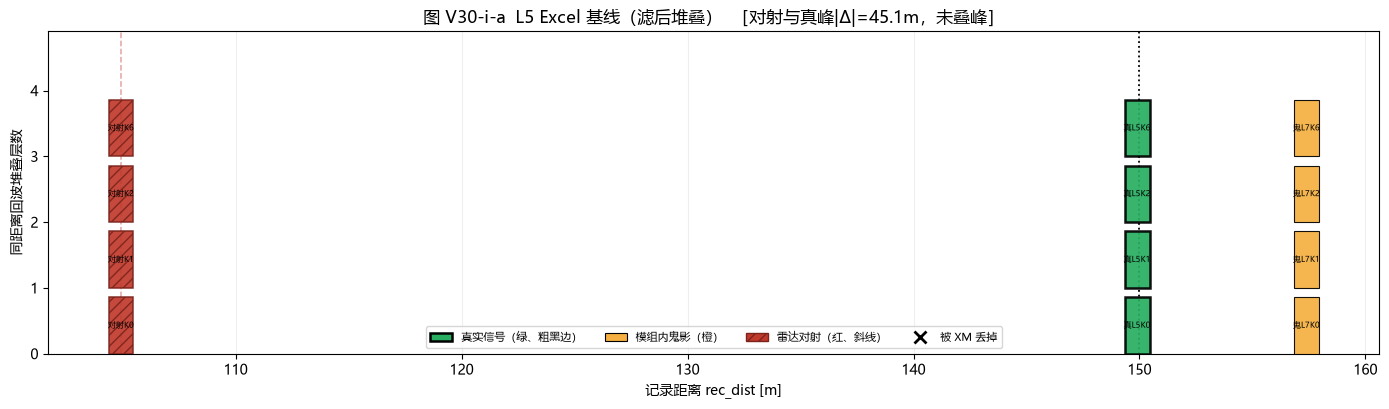

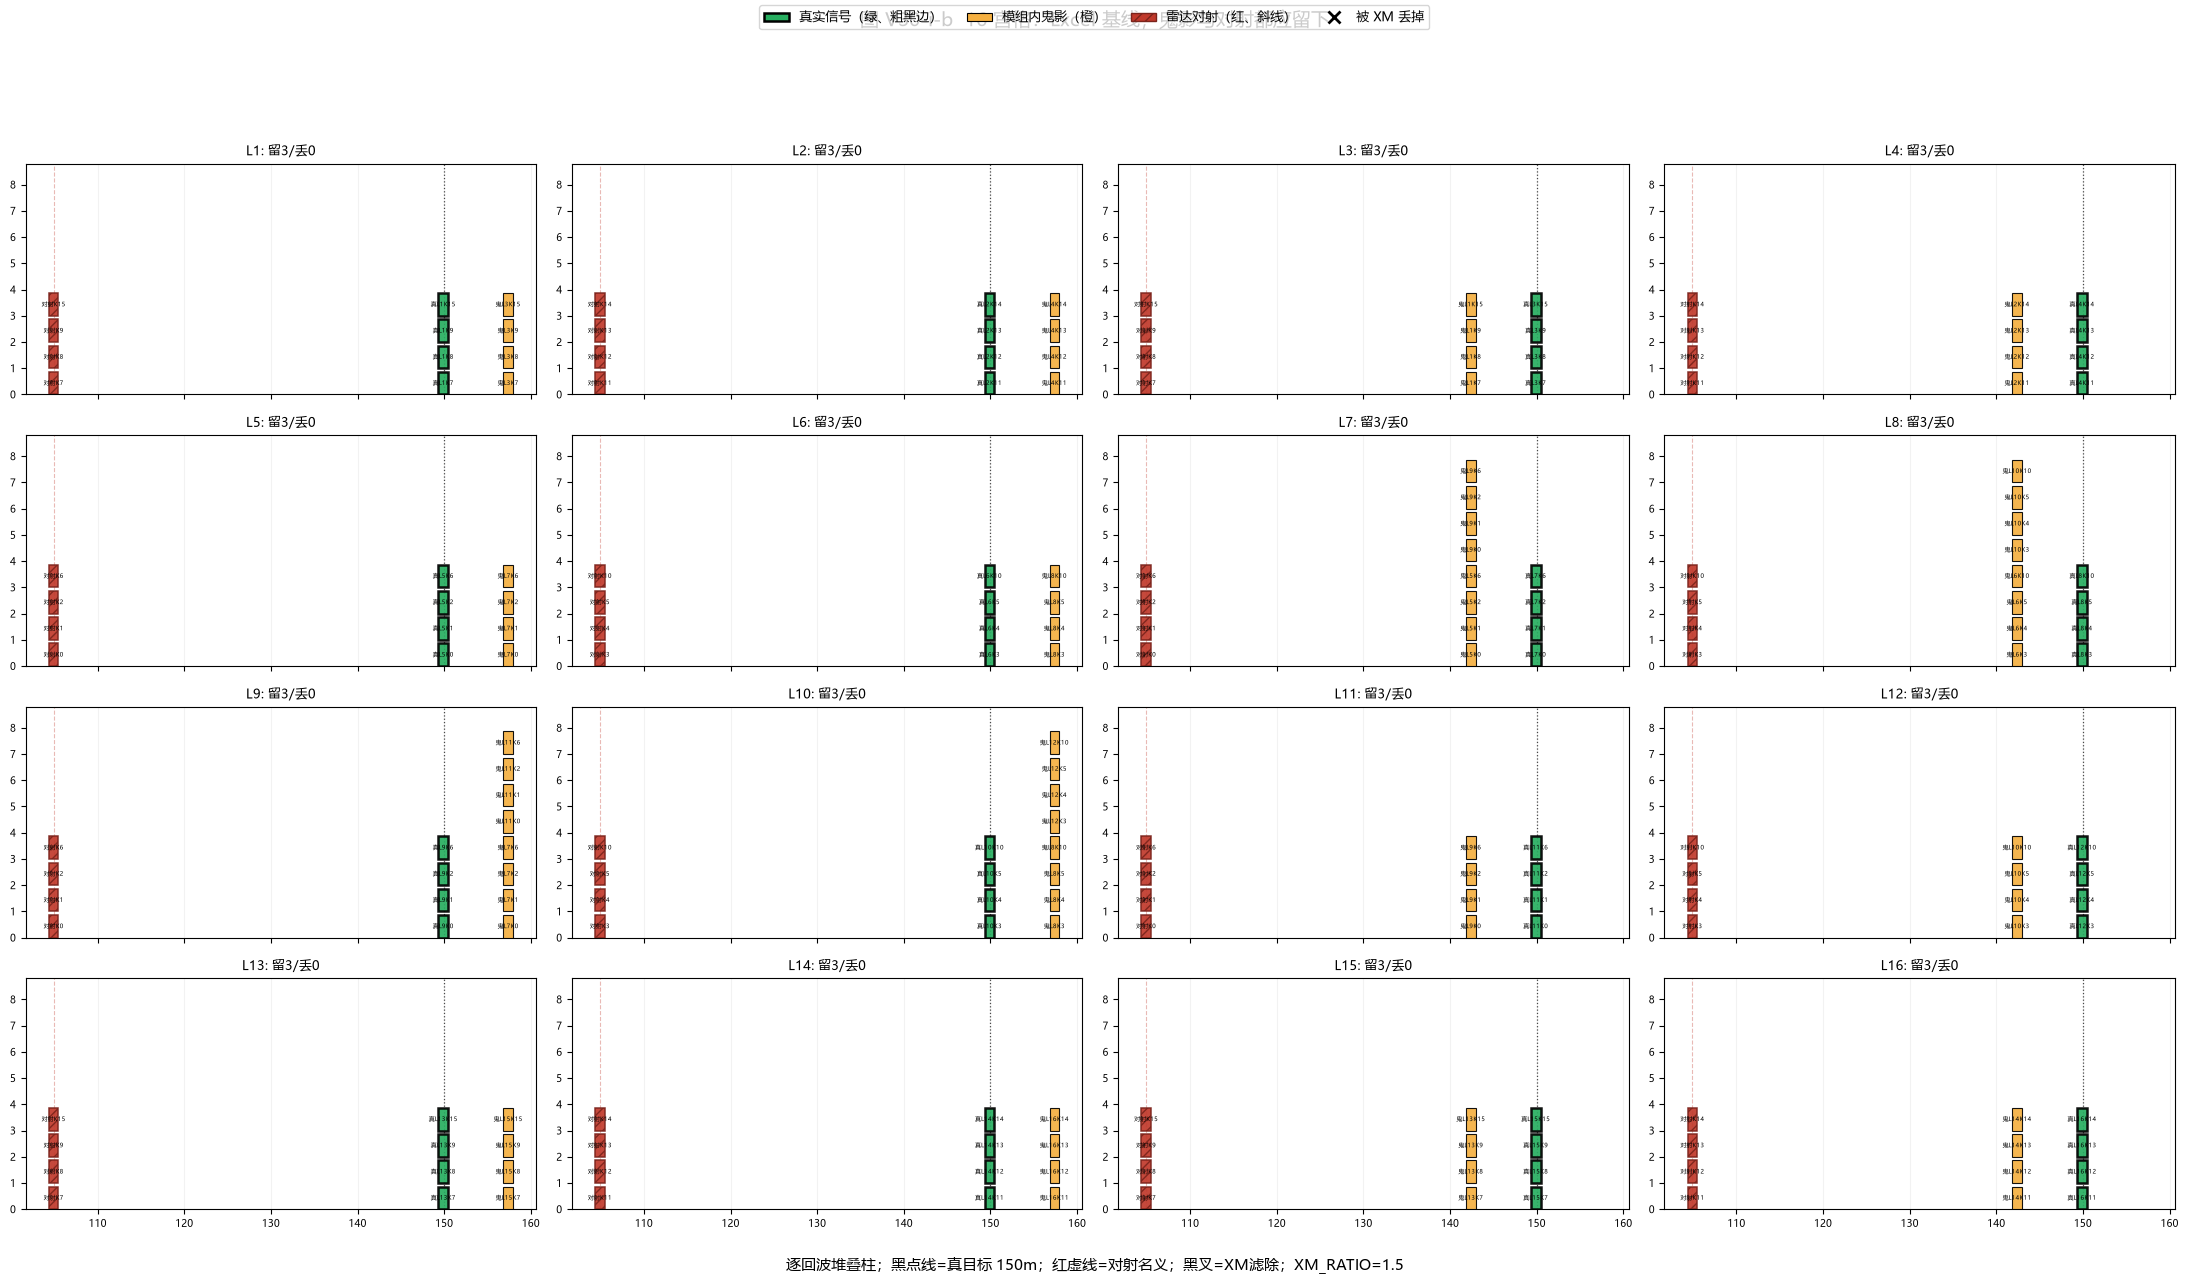

In [8]:
# ============================================================================
# 4.i  Excel 时序 + 对射/鬼影（基线）
# ============================================================================
S_i = run_scene(use_tcode=False, use_fpga=False)
stat_i = print_stats("i Excel + 对射", S_i["hs"], S_i["rs"])
plot_echo_channel(S_i["hs"], S_i["rs"], SCENE["demo_laser"],
                  f"图 V30-i-a  L{SCENE['demo_laser']} Excel 基线（滤后堆叠）",
                  S_i["D"])
plot_echo_grid(S_i["hs"], S_i["rs"],
               f"图 V30-i-b  16 宫格：Excel 基线，鬼影与对射都应留下",
               S_i["D"])


# 4.ii  加入 tcode

模组内鬼影应被打散并被 XM 丢掉；对射仍在。


【ii tcode(1.5) + 对射】峰级统计
        类型     保留     丢弃
       纯真峰     16      0
       纯鬼峰      0     71
      纯对射峰     16      0
       混合峰      0      0


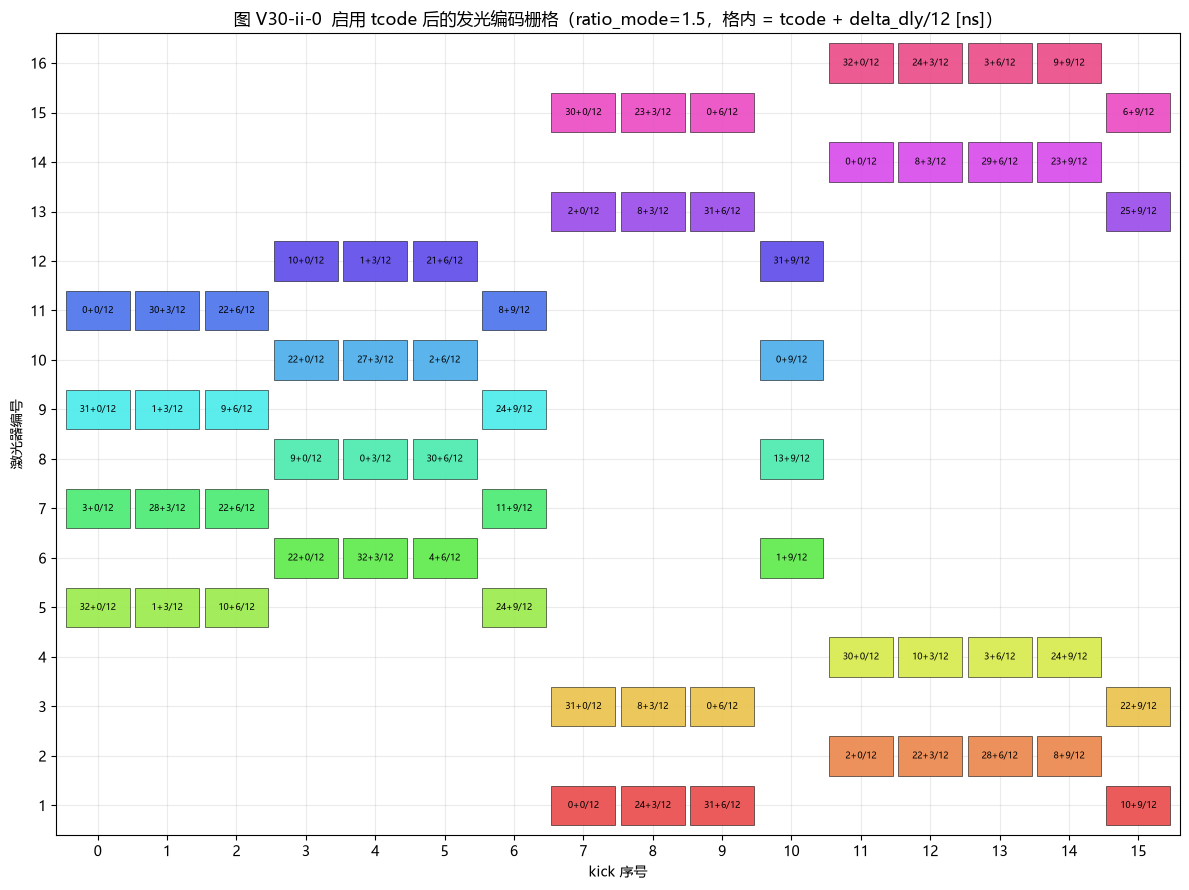

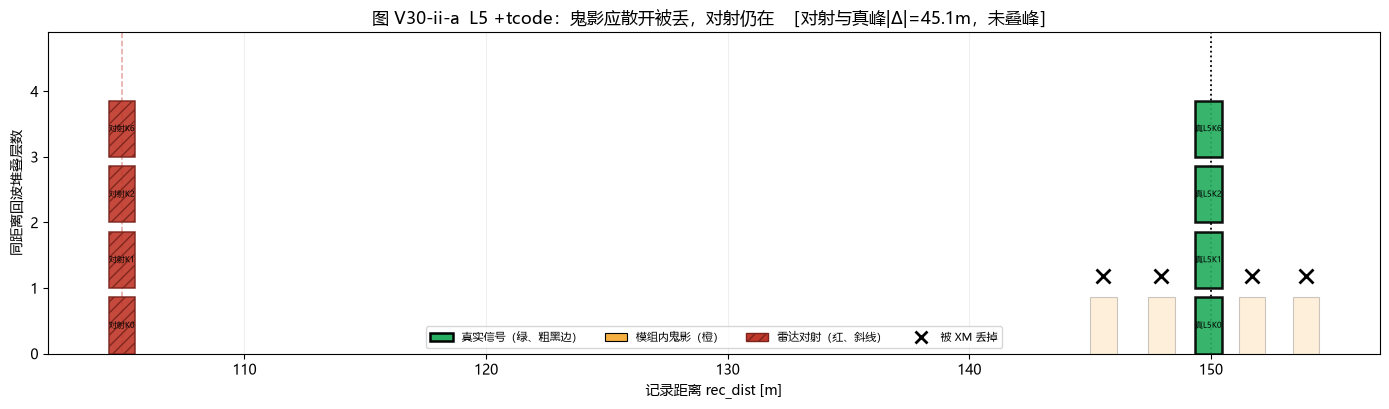

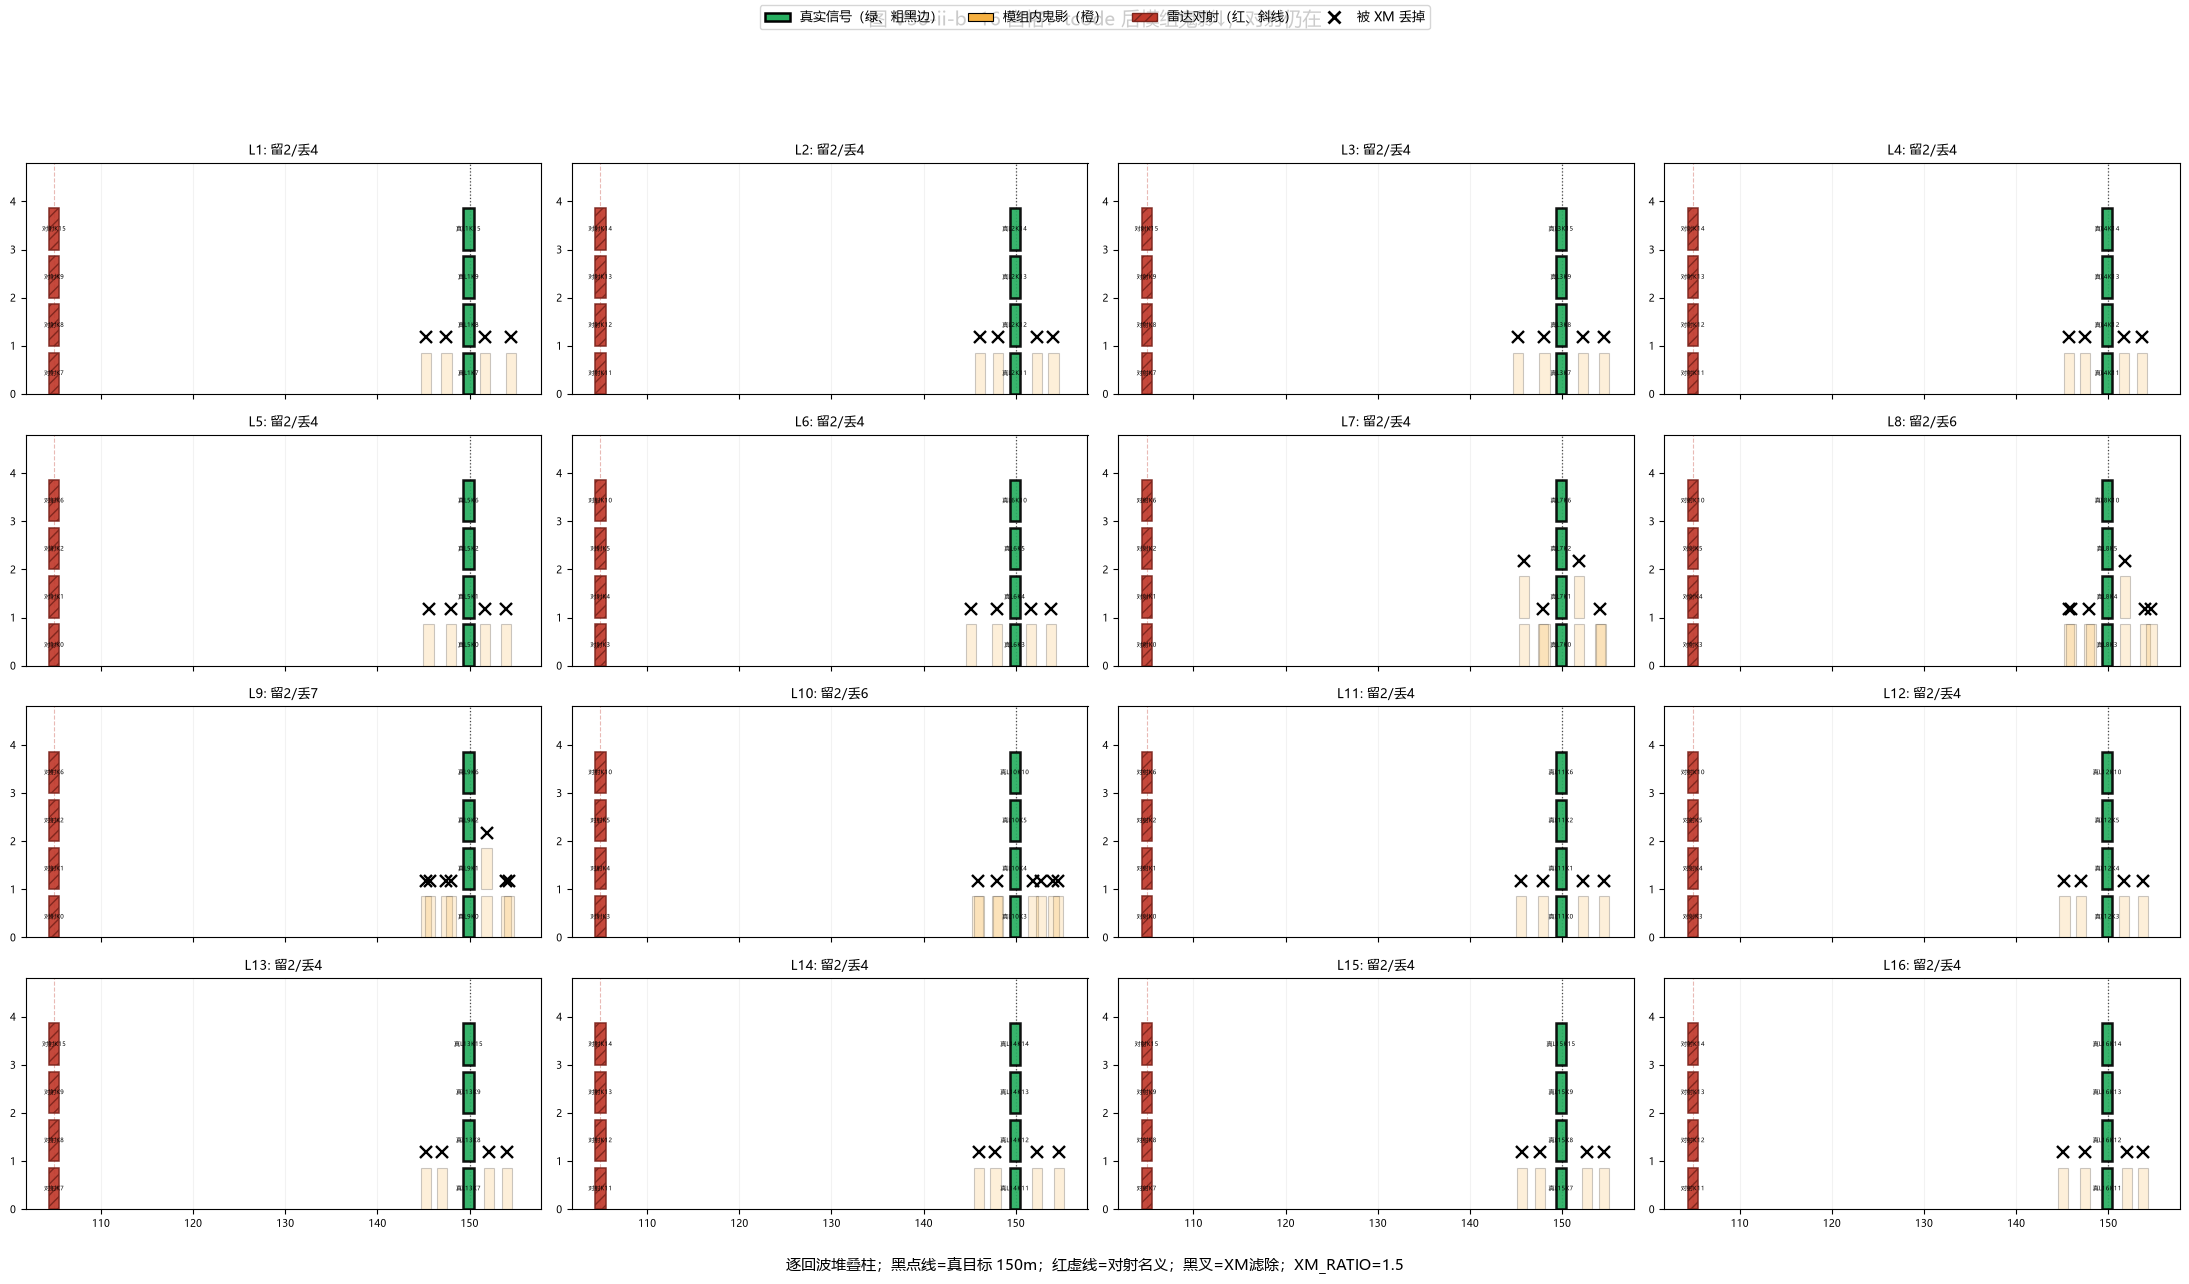

In [9]:
# ============================================================================
# 4.ii  + tcode
# ============================================================================
S_ii = run_scene(use_tcode=True, use_fpga=False)
stat_ii = print_stats(f"ii tcode({TCODE['ratio_mode']}) + 对射",
                      S_ii["hs"], S_ii["rs"])
plot_kick_grid(
    lambda lid, k: code_label(active_tx(lid, k, use_tcode=True), k),
    f"图 V30-ii-0  启用 tcode 后的发光编码栅格"
    f"（ratio_mode={TCODE['ratio_mode']}，格内 = tcode + delta_dly/12 [ns]）")
plot_echo_channel(S_ii["hs"], S_ii["rs"], SCENE["demo_laser"],
                  f"图 V30-ii-a  L{SCENE['demo_laser']} +tcode：鬼影应散开被丢，对射仍在",
                  S_ii["D"])
plot_echo_grid(S_ii["hs"], S_ii["rs"],
               f"图 V30-ii-b  16 宫格：tcode 后模组鬼影↓，对射仍在",
               S_ii["D"])


# 4.iii  加入双方 FPGA 累计抖动

最坏对射：同型号、同时序、同 tcode；**我方与对射雷达都有 FPGA**。
相对落点 $$(\phi + d_{\mathrm{radar}} - d_{\mathrm{ours}})\bmod T_{\mathrm{kick}}$$。


【iii tcode + 双方 FPGA + 对射】峰级统计
        类型     保留     丢弃
       纯真峰     16      0
       纯鬼峰      0     71
      纯对射峰      8     48
       混合峰      0      0


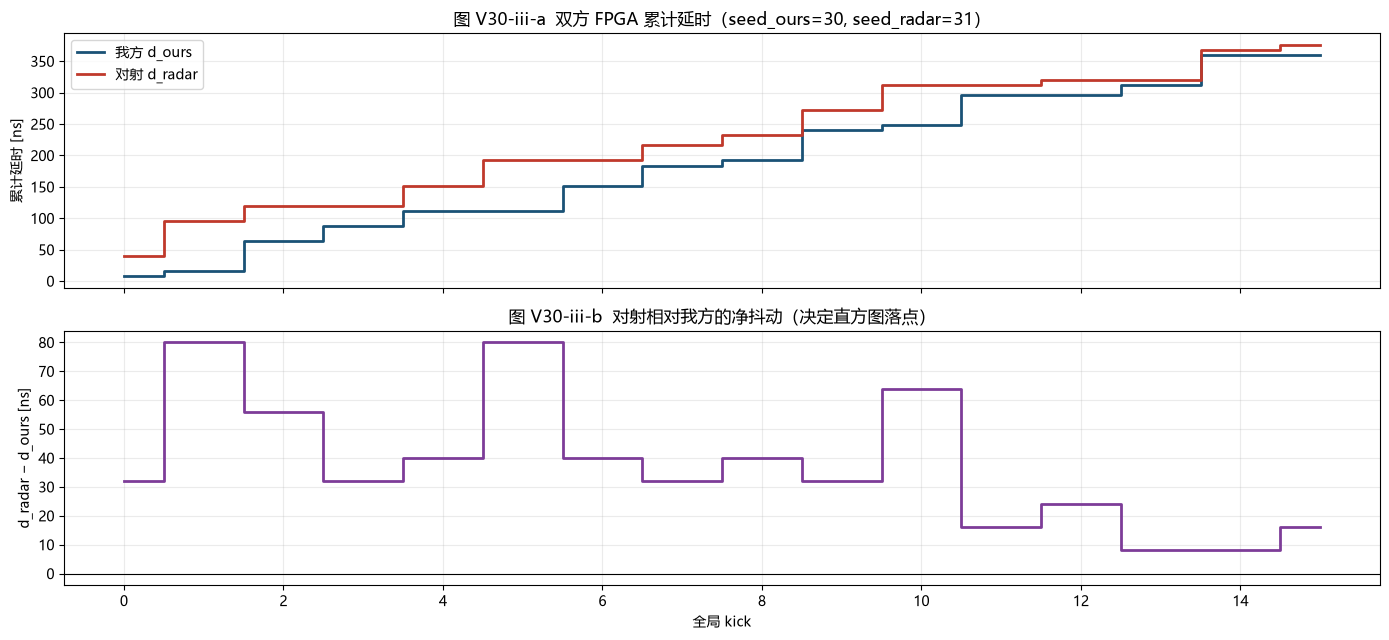

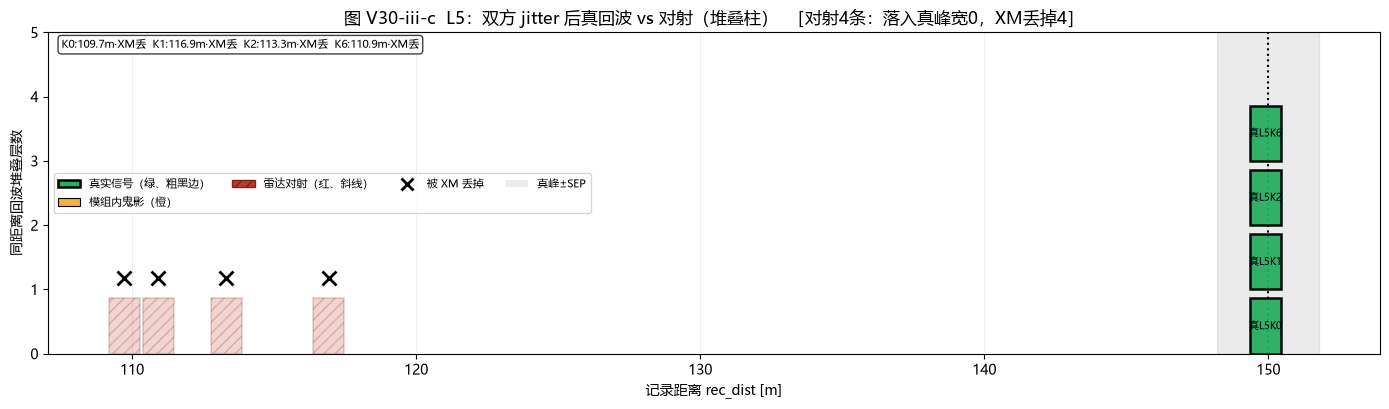

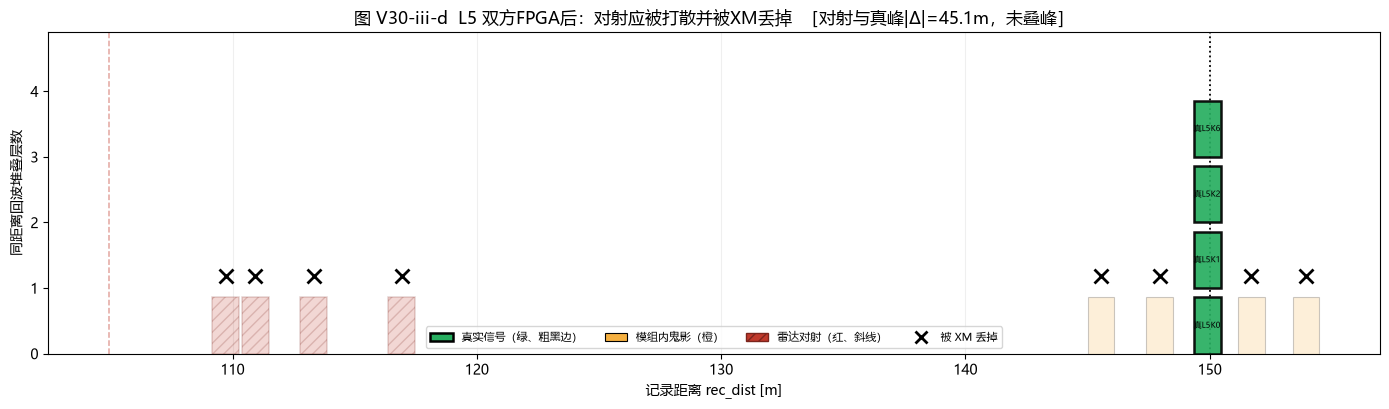

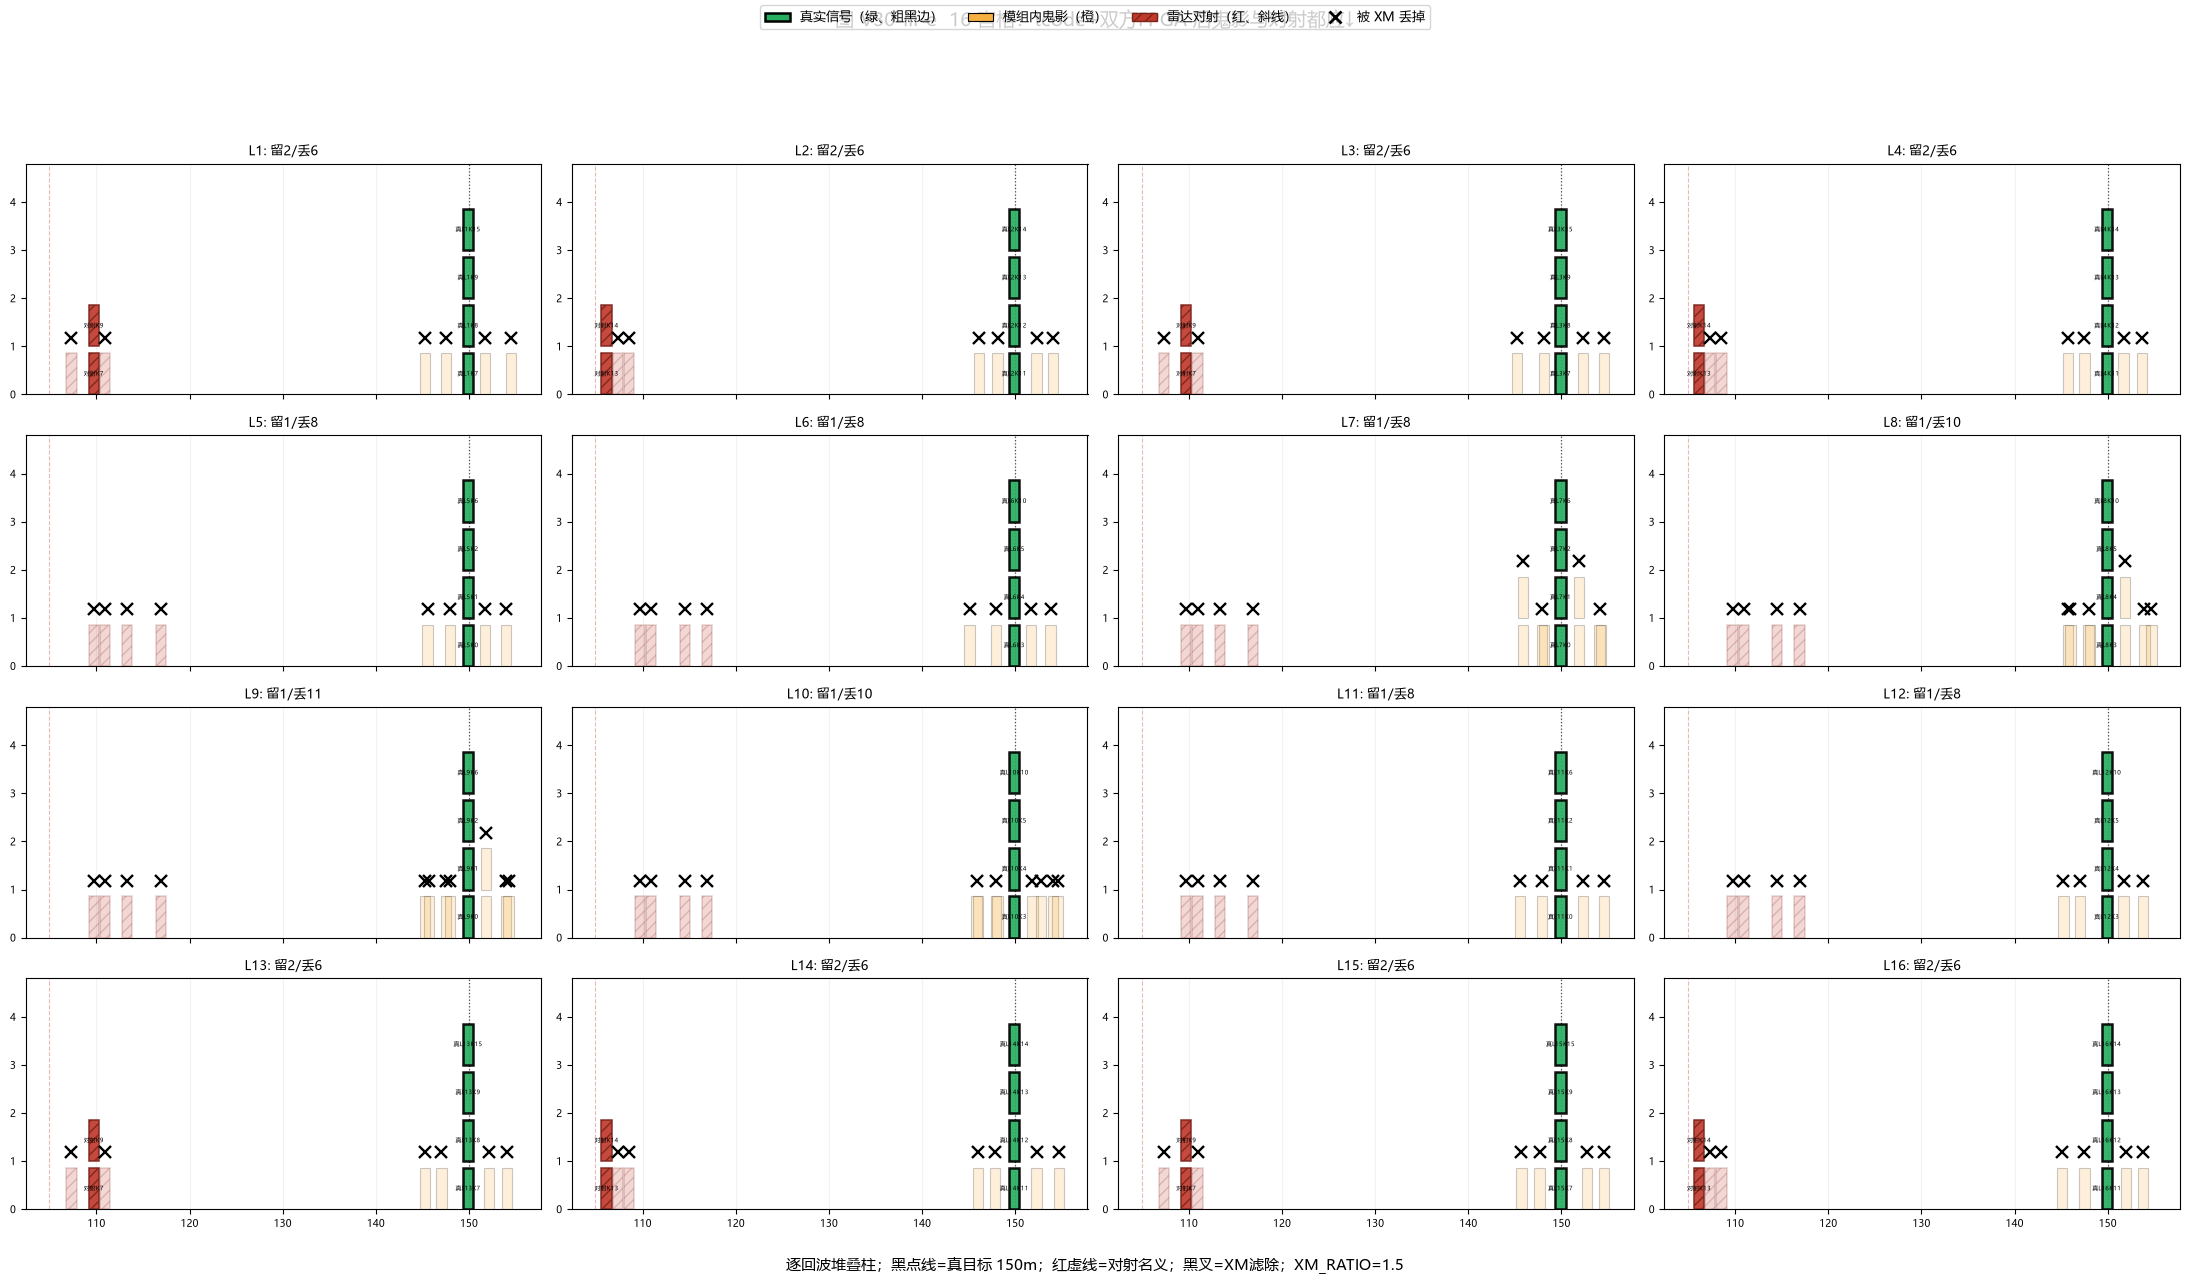

In [10]:
# ============================================================================
# 4.iii  + FPGA（我方 + 对射雷达双方累计抖动）
# ============================================================================
# 最坏设定：同型号 / 同时序 / 同 tcode；双方独立 FPGA 种子
assert RADAR["same_model"] and RADAR["same_timing"] and RADAR["same_tcode"]
S_iii = run_scene(use_tcode=True, use_fpga=True)
stat_iii = print_stats("iii tcode + 双方 FPGA + 对射", S_iii["hs"], S_iii["rs"])

# 相对抖动轨迹
fig, axes = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True)
axes[0].step(range(16), S_iii["cum_ours"][0], where="mid", lw=2.0,
             color="#1a5276", label="我方 d_ours")
axes[0].step(range(16), S_iii["cum_radar"][0], where="mid", lw=2.0,
             color=RADAR_COLOR, label="对射 d_radar")
axes[0].set_ylabel("累计延时 [ns]")
axes[0].set_title(f"图 V30-iii-a  双方 FPGA 累计延时"
                  f"（seed_ours={FPGA['seed_ours']}, seed_radar={FPGA['seed_radar']}）")
axes[0].legend(); axes[0].grid(alpha=0.25)
rel = S_iii["cum_radar"][0] - S_iii["cum_ours"][0]
axes[1].step(range(16), rel, where="mid", lw=2.0, color="#7d3c98")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("全局 kick")
axes[1].set_ylabel("d_radar − d_ours [ns]")
axes[1].set_title("图 V30-iii-b  对射相对我方的净抖动（决定直方图落点）")
axes[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()

lid = SCENE["demo_laser"]
plot_true_radar_stack(
    S_iii["hs"], S_iii["rs"], lid,
    f"图 V30-iii-c  L{lid}：双方 jitter 后真回波 vs 对射（堆叠柱）",
    S_iii["D"])

plot_echo_channel(S_iii["hs"], S_iii["rs"], lid,
                  f"图 V30-iii-d  L{lid} 双方FPGA后：对射应被打散并被XM丢掉",
                  S_iii["D"])
plot_echo_grid(S_iii["hs"], S_iii["rs"],
               "图 V30-iii-e  16 宫格：tcode+双方FPGA 后鬼影与对射都应↓",
               S_iii["D"])


# 4.iv  加入一字滤波

左/中/右 = **三次独立的 iii 仿真**：tcode + 双方 FPGA + 对射均开启；
雷达参数（phase / same_*）不变，仅 FPGA 种子不同（中 = 步骤 iii 种子，左右见 `LINE.seed_*`）。

中间角度 XM 后保留的峰，若相对左右最近峰距离差都 > thr → 判角度孤立并丢掉。由此可检验对射残留是否因三次随机落点不一致而被一字清掉。


【iv-左 (seed_o=40, seed_r=41)】峰级统计
        类型     保留     丢弃
       纯真峰     16      0
       纯鬼峰      0     71
      纯对射峰      4     56
       混合峰      0      0

【iv-中 (seed_o=30, seed_r=31)】峰级统计
        类型     保留     丢弃
       纯真峰     16      0
       纯鬼峰      0     71
      纯对射峰      8     48
       混合峰      0      0

【iv-右 (seed_o=44, seed_r=45)】峰级统计
        类型     保留     丢弃
       纯真峰     16      0
       纯鬼峰      0     71
      纯对射峰      4     56
       混合峰      0      0

【iv 一字滤波】一字滤波 thr=3.0m
  真峰留下 16；对射留下 0 / 丢掉 8；鬼影留下 0


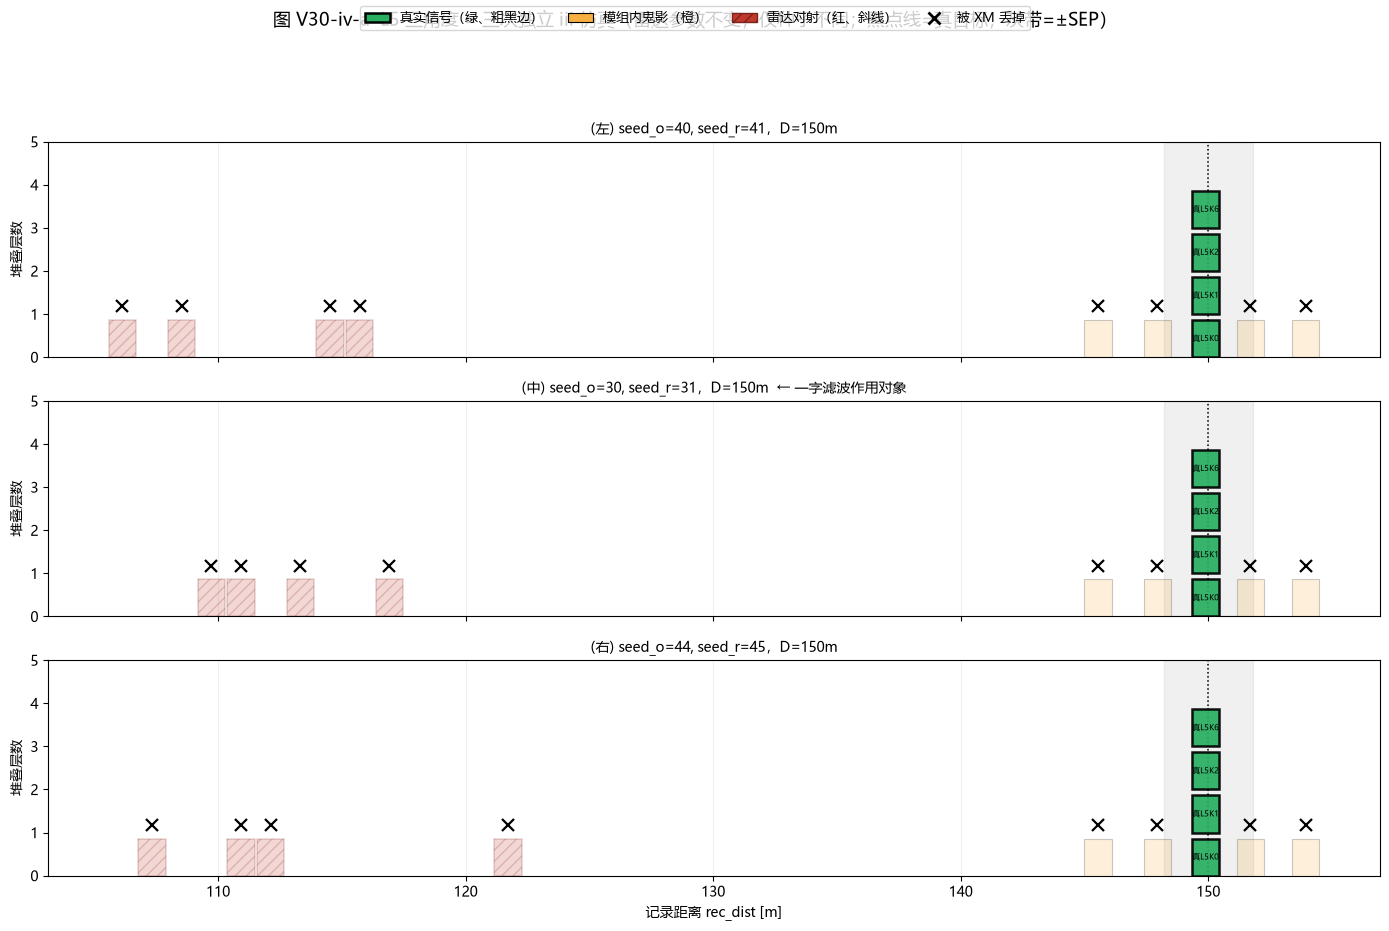

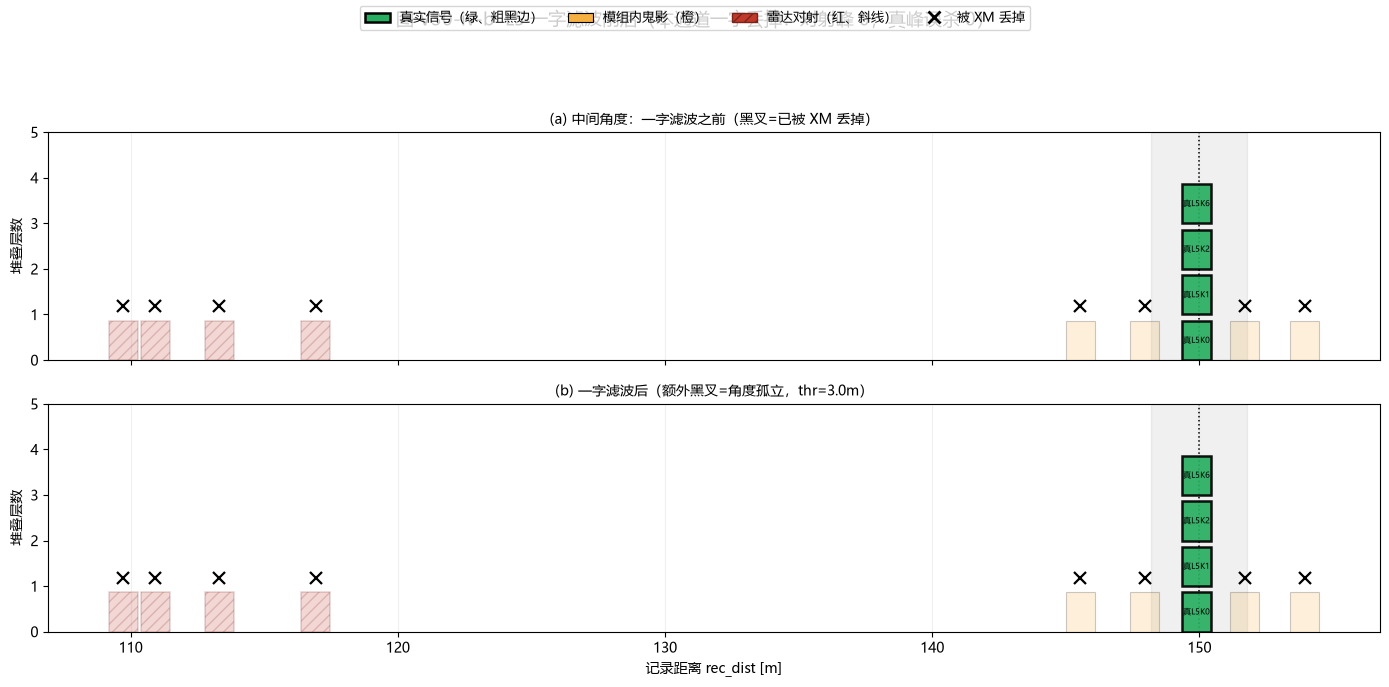


三角度种子：左(40/41) 中(30/31) 右(44/45)
雷达参数不变：phase=700.0ns，same_model/timing/tcode=True/True/True


In [11]:
# ============================================================================
# 4.iv  + 一字滤波（三角度 = 三次独立的 iii 仿真）
# ============================================================================
# 雷达参数不变（phase / same_*）；每次仿真换一对 FPGA 种子。
# 中间角度沿用步骤 iii 的种子，左右用 LINE 里另设的种子。

def run_iii_angle(D, seed_ours, seed_radar, tag):
    assert RADAR["enable"], "一字滤波要求雷达对射开启（与 iii 同配置）"
    out = run_scene(use_tcode=True, use_fpga=True, D=D,
                    seed_ours=seed_ours, seed_radar=seed_radar)
    c = print_stats(f"iv-{tag} (seed_o={seed_ours}, seed_r={seed_radar})",
                    out["hs"], out["rs"])
    out["stat"] = c
    return out


A_L = run_iii_angle(SCENE["line_D_left_m"],
                    LINE["seed_ours_left"], LINE["seed_radar_left"], "左")
A_M = run_iii_angle(SCENE["line_D_mid_m"],
                    FPGA["seed_ours"], FPGA["seed_radar"], "中")
A_R = run_iii_angle(SCENE["line_D_right_m"],
                    LINE["seed_ours_right"], LINE["seed_radar_right"], "右")

line_iv = line_filter_all(A_L["rs"], A_M["rs"], A_R["rs"])
stat_iv = summarize_line("iv 一字滤波", line_iv, A_M["hs"])

lid = SCENE["demo_laser"]
sep_m = TCODE["sep_ns"] * NS * C_LIGHT / 2.0


def _stack_on_ax(ax, ang, title, line_res=None):
    """在给定 ax 上画逐回波堆叠柱；若给 line_res，则黑叉标一字丢掉。"""
    h, rr = ang["hs"][lid], ang["rs"][lid]
    b_lo, b_hi = occupied_range({lid: h}, pad=25)
    ymax = 1
    for b in range(b_lo, b_hi + 1):
        q = peak_for_bin(rr, b)
        xm_drop = bool(q and q["is_xtalk"])
        for level, rec in enumerate(h["src"].get(b, [])):
            xc = b * HIST_BIN_M
            st = rec_style(rec, alpha=0.20 if xm_drop else 0.92)
            ax.add_patch(plt.Rectangle(
                (xc - 0.55, level), 1.1, 0.86, zorder=3, **st))
            if not xm_drop:
                ax.text(xc, level + 0.43, rec_label(rec),
                        ha="center", va="center", fontsize=5.5, zorder=4)
            ymax = max(ymax, level + 1)
    # XM 丢掉
    for q in rr["peaks"]:
        if q["is_xtalk"]:
            ax.plot(q["dist"], q["add"] + 0.18, "kx", ms=8, mew=1.6, zorder=6)
    # 一字丢掉（仅中间）
    if line_res is not None:
        for q in line_res[lid]["peaks"]:
            if q["is_line_ghost"]:
                ax.plot(q["dist"], max(q["add"], 0.3) + 0.35, "kx",
                        ms=11, mew=2.2, zorder=7)
    ax.axvline(ang["D"], color="k", ls=":", lw=1.1)
    ax.axvspan(ang["D"] - sep_m, ang["D"] + sep_m, color="k", alpha=0.06)
    ax.set_ylim(0, ymax + 1.0)
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.18, axis="x")
    return b_lo, b_hi


# ---- 图 iv-a：三角度各自是一次完整 iii（堆叠柱）----
fig, axes = plt.subplots(3, 1, figsize=(14, 9.5), sharex=True)
_stack_on_ax(axes[0], A_L,
             f"(左) seed_o={A_L['seed_ours']}, seed_r={A_L['seed_radar']}，"
             f"D={A_L['D']:.0f}m")
_stack_on_ax(axes[1], A_M,
             f"(中) seed_o={A_M['seed_ours']}, seed_r={A_M['seed_radar']}，"
             f"D={A_M['D']:.0f}m  ← 一字滤波作用对象")
_stack_on_ax(axes[2], A_R,
             f"(右) seed_o={A_R['seed_ours']}, seed_r={A_R['seed_radar']}，"
             f"D={A_R['D']:.0f}m")
axes[2].set_xlabel("记录距离 rec_dist [m]")
for ax in axes:
    ax.set_ylabel("堆叠层数")
fig.legend(handles=type_legend(), loc="upper center", ncol=4, fontsize=9)
fig.suptitle(f"图 V30-iv-a  L{lid} 三角度 = 三次独立 iii 仿真"
             f"（雷达参数不变，仅种子不同；黑点线=真目标，灰带=±SEP）",
             fontsize=13, y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.93]); plt.show()

# ---- 图 iv-b：中间角度 XM 后 vs 一字后（堆叠柱 + 黑叉）----
fig, axes = plt.subplots(2, 1, figsize=(14, 7.0), sharex=True)
_stack_on_ax(axes[0], A_M,
             "(a) 中间角度：一字滤波之前（黑叉=已被 XM 丢掉）")
_stack_on_ax(axes[1], A_M,
             f"(b) 一字滤波后（额外黑叉=角度孤立，thr={LINE['thr_m']:.1f}m）",
             line_res=line_iv)
axes[1].set_xlabel("记录距离 rec_dist [m]")
for ax in axes:
    ax.set_ylabel("堆叠层数")
# 标出一字丢掉的对射/真峰
n_radar_line_drop = 0
n_true_line_drop = 0
for q in line_iv[lid]["peaks"]:
    if not q["is_line_ghost"]:
        continue
    recs = [r for b in range(q["s"], q["e"] + 1)
            for r in A_M["hs"][lid]["src"].get(b, [])]
    if any(r.get("is_radar") for r in recs):
        n_radar_line_drop += 1
    if any(r.get("is_true") for r in recs):
        n_true_line_drop += 1
fig.legend(handles=type_legend(), loc="upper center", ncol=4, fontsize=9)
fig.suptitle(f"图 V30-iv-b  L{lid} 一字滤波前后"
             f"（本通道一字丢掉：对射峰 {n_radar_line_drop}，真峰误杀 {n_true_line_drop}）",
             fontsize=13, y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.92]); plt.show()

print(f"\n三角度种子：左({A_L['seed_ours']}/{A_L['seed_radar']}) "
      f"中({A_M['seed_ours']}/{A_M['seed_radar']}) "
      f"右({A_R['seed_ours']}/{A_R['seed_radar']})")
print(f"雷达参数不变：phase={RADAR['phase_ns']}ns，"
      f"same_model/timing/tcode="
      f"{RADAR['same_model']}/{RADAR['same_timing']}/{RADAR['same_tcode']}")


四步对比（D=150m，XM_RATIO=1.5，tcode.consider_gap=True，XM.use_pulse_width=False）
  步骤                        真保留    鬼保留    鬼丢掉     对射保留     对射丢掉
  ----------------------------------------------------------------------
  i Excel                    16     16      0       16        0
  ii tcode(1.5)              16      0     71       16        0
  iii +双方FPGA                16      0     71        8       48
  iv 一字滤波                真留=16  对射留/丢=0/8  鬼留=0


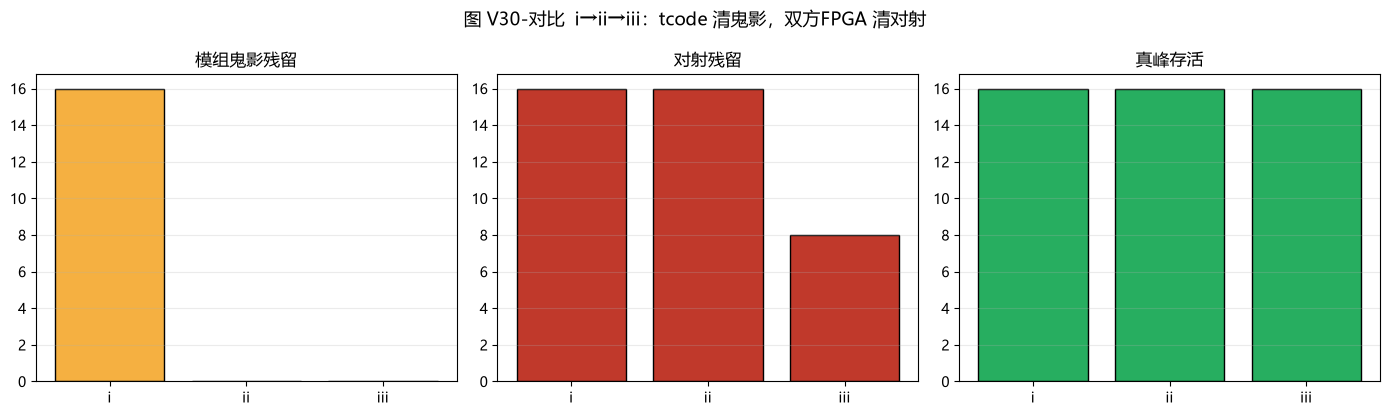

In [12]:
# ============================================================================
# 5. 四步对比
# ============================================================================
rows = [
    ("i Excel", stat_i),
    (f"ii tcode({TCODE['ratio_mode']})", stat_ii),
    ("iii +双方FPGA", stat_iii),
]
print("=" * 88)
print(f"四步对比（D={SCENE['demo_D_m']:.0f}m，XM_RATIO={XM['ratio']}，"
      f"tcode.consider_gap={TCODE['consider_gap']}，"
      f"XM.use_pulse_width={XM['use_pulse_width']}）")
print("=" * 88)
print(f"  {'步骤':<22} {'真保留':>6} {'鬼保留':>6} {'鬼丢掉':>6} "
      f"{'对射保留':>8} {'对射丢掉':>8}")
print("  " + "-" * 70)
for name, c in rows:
    print(f"  {name:<22} {c[('纯真峰','保留')]:>6d} "
          f"{c[('纯鬼峰','保留')]:>6d} {c[('纯鬼峰','丢弃')]:>6d} "
          f"{c[('纯对射峰','保留')]:>8d} {c[('纯对射峰','丢弃')]:>8d}")
print(f"  {'iv 一字滤波':<22} 真留={stat_iv['true_keep']}  "
      f"对射留/丢={stat_iv['fake_keep']}/{stat_iv['fake_drop']}  "
      f"鬼留={stat_iv['ghost_keep']}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
labels = ["i", "ii", "iii"]
axes[0].bar(labels, [c[("纯鬼峰", "保留")] for _, c in rows],
            color=GHOST_COLOR, edgecolor="k")
axes[0].set_title("模组鬼影残留")
axes[1].bar(labels, [c[("纯对射峰", "保留")] for _, c in rows],
            color=RADAR_COLOR, edgecolor="k")
axes[1].set_title("对射残留")
axes[2].bar(labels, [c[("纯真峰", "保留")] for _, c in rows],
            color=TRUE_COLOR, edgecolor="k")
axes[2].set_title("真峰存活")
for ax in axes:
    ax.grid(alpha=0.25, axis="y")
plt.suptitle("图 V30-对比  i→ii→iii：tcode 清鬼影，双方FPGA 清对射", fontsize=13)
plt.tight_layout(); plt.show()


In [13]:
# ============================================================================
# 6. 总结
# ============================================================================
print("=" * 78)
print("crosstalk_sim_v30 总结")
print("=" * 78)
print(f"""
【参数开关】
  tcode.consider_gap    = {TCODE['consider_gap']}（激光不串扰距离）
  XM.use_pulse_width    = {XM['use_pulse_width']}（信号脉宽；本版关=δ回波）
  TIMING.use_tx_trig_dly= {TIMING['use_tx_trig_dly']}
  TIMING.use_delta_dly  = {TIMING['use_delta_dly']}（1/12ns 步长；本版关，仅栅格展示）
  XM.ratio = {XM['ratio']}；TCODE.ratio_mode = {TCODE['ratio_mode']}
  tcode 预算 = {active_budget()}ns（gap>2 可忽略 · 零残留前提下的最短预算）

【四步】
  i   Excel            → 鬼影+对射都稳
  ii  +tcode           → 鬼影↓，对射仍在
  iii +双方FPGA        → 对射相对抖动，XM 可清
  iv  +一字滤波        → 三角度独立 iii（种子不同）清对射孤点

【绘图】
  时序栅格 / tcode 矩阵 / 逐回波堆叠柱（绿真·橙鬼·红斜线对射·黑叉滤除）
""")


crosstalk_sim_v30 总结

【参数开关】
  tcode.consider_gap    = True（激光不串扰距离）
  XM.use_pulse_width    = False（信号脉宽；本版关=δ回波）
  TIMING.use_tx_trig_dly= True
  TIMING.use_delta_dly  = False（1/12ns 步长；本版关，仅栅格展示）
  XM.ratio = 1.5；TCODE.ratio_mode = 1.5
  tcode 预算 = 32ns（gap>2 可忽略 · 零残留前提下的最短预算）

【四步】
  i   Excel            → 鬼影+对射都稳
  ii  +tcode           → 鬼影↓，对射仍在
  iii +双方FPGA        → 对射相对抖动，XM 可清
  iv  +一字滤波        → 三角度独立 iii（种子不同）清对射孤点

【绘图】
  时序栅格 / tcode 矩阵 / 逐回波堆叠柱（绿真·橙鬼·红斜线对射·黑叉滤除）

